# Outdoors5 — Stereo Visual Odometry Final Notebook

This notebook is the **Outdoors5** version of your clean modular Stereo VO pipeline.

Rules followed:
- official dataset frames are used;
- official TUM-VI calibration from `dso/camchain.yaml` is used;
- ground truth is read-only and used only for evaluation;
- no deep learning;
- outputs are saved for GitHub/report submission: TUM trajectories, CSV tables, plots, frame stats, and config JSON.

For Outdoors5, the notebook uses a **start-end drift evaluation protocol** if the GT contains gaps.

## 1. Setup, imports, paths, and reproducibility

In [1]:
import sys
import os
import time
import json
import platform
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ROOT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo")

# Support both possible repo layouts:
#   Stereo_vo/stereo_vo1/stereo_vo
#   Stereo_vo/stereo_vo
PACKAGE_CANDIDATES = [
    ROOT_DIR / "stereo_vo1",
    ROOT_DIR,
]

for p in PACKAGE_CANDIDATES:
    if (p / "stereo_vo").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("Current notebook folder:", os.getcwd())
print("Data root:", ROOT_DIR)
print("Package candidates:")
for p in PACKAGE_CANDIDATES:
    print(" ", p, "->", (p / "stereo_vo").exists())

from stereo_vo.dataset import TumVIDataset
from stereo_vo.calibration import (
    load_kalibr_camchain,
    build_fisheye_rectifier,
    rectify_stereo_pair,
    load_camchain,
    get_camera_imu_transform,
)
from stereo_vo.monocular_vo import run_monocular_vo
from stereo_vo.evaluation import (
    load_gt_camera_poses,
    poses_to_xyz,
    sim3_align,
    rigid_align_3d,
    poses_to_tum_array,
)

import importlib
import stereo_vo.features as features_module
import stereo_vo.stereo_vo as stereo_module

importlib.reload(features_module)
importlib.reload(stereo_module)

run_stereo_vo_rectified = stereo_module.run_stereo_vo_rectified

print("\n==============================")
print("REPRODUCIBILITY INFO")
print("==============================")
print("OS:", platform.platform())
print("Python:", sys.version)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Random seed:", RANDOM_SEED)
print("Stereo module:", stereo_module.__file__)

Current notebook folder: c:\Users\User\Downloads
Data root: C:\Users\User\Desktop\Stereo_vo
Package candidates:
  C:\Users\User\Desktop\Stereo_vo\stereo_vo1 -> False
  C:\Users\User\Desktop\Stereo_vo -> True

REPRODUCIBILITY INFO
OS: Windows-10-10.0.26200-SP0
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
OpenCV: 4.13.0
NumPy: 2.4.4
Random seed: 42
Stereo module: C:\Users\User\Desktop\Stereo_vo\stereo_vo\stereo_vo.py


## 2. Outdoors5 dataset configuration

In [2]:
ACTIVE_DATASET = "outdoors5"

RUN_MONO = True
RUN_STEREO = True

DATASET_DIR = ROOT_DIR / "dataset-outdoors5_512_16"
OUTPUT_DIR = ROOT_DIR / "outputs" / "outdoors5_final_submission"

CONFIG_DIR = OUTPUT_DIR / "configs"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
TRAJ_DIR = OUTPUT_DIR / "trajectories"

for d in [OUTPUT_DIR, CONFIG_DIR, TABLE_DIR, PLOT_DIR, TRAJ_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Conservative classical Stereo VO parameters for Outdoors5.
# use_fundamental=False avoids occasional OpenCV degenerate F-matrix crashes.
OUTDOORS5_STEREO_PARAMS = dict(
    feature_type="orb",
    nfeatures=3000,
    ratio=0.72,
    top_k=300,
    cross_check=True,
    use_fundamental=False,
    max_motion=120.0,

    min_disp=0.7,
    max_depth=20.0,
    min_depth=0.2,
    patch_radius=2,

    min_corr=30,
    min_inliers=25,

    t_norm_min=0.0003,
    t_norm_max=0.35,
    rot_angle_max=18.0,

    use_hybrid=False,
    use_wls=True,
    max_reprojection_rmse=3.0,

    skip_first_n=0,
    invert_pose_update=True,
)

print("Active dataset:", ACTIVE_DATASET)
print("Dataset directory:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())
print("Output directory:", OUTPUT_DIR)

Active dataset: outdoors5
Dataset directory: C:\Users\User\Desktop\Stereo_vo\dataset-outdoors5_512_16
Dataset exists: True
Output directory: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission


## 3. Safety patch for OpenCV Fundamental-matrix filtering

In [3]:
def filter_matches_fundamental_safe(kp1, kp2, matches, reproj_thresh=1.5):
    if matches is None:
        return []

    matches = list(matches)
    if len(matches) < 8:
        return matches

    pts1, pts2, valid_matches = [], [], []
    n1, n2 = len(kp1), len(kp2)

    for m in matches:
        try:
            if m.queryIdx < 0 or m.queryIdx >= n1:
                continue
            if m.trainIdx < 0 or m.trainIdx >= n2:
                continue

            p1 = kp1[m.queryIdx].pt
            p2 = kp2[m.trainIdx].pt

            if not np.all(np.isfinite(p1)) or not np.all(np.isfinite(p2)):
                continue

            pts1.append(p1)
            pts2.append(p2)
            valid_matches.append(m)
        except Exception:
            continue

    if len(valid_matches) < 8:
        return valid_matches

    pts1 = np.ascontiguousarray(np.asarray(pts1, dtype=np.float32).reshape(-1, 2))
    pts2 = np.ascontiguousarray(np.asarray(pts2, dtype=np.float32).reshape(-1, 2))

    if len(np.unique(pts1, axis=0)) < 8 or len(np.unique(pts2, axis=0)) < 8:
        return valid_matches

    try:
        F, mask = cv2.findFundamentalMat(
            pts1,
            pts2,
            cv2.FM_RANSAC,
            ransacReprojThreshold=float(reproj_thresh),
            confidence=0.99,
            maxIters=2000,
        )
    except cv2.error as e:
        print("WARNING: findFundamentalMat failed. Keeping valid matches.")
        print(e)
        return valid_matches

    if F is None or mask is None:
        return valid_matches

    mask = mask.ravel().astype(bool)
    if len(mask) != len(valid_matches):
        return valid_matches

    filtered = [m for m, keep in zip(valid_matches, mask) if keep]
    if len(filtered) < 8:
        return valid_matches

    return filtered


patched = []
for module_name, module in list(sys.modules.items()):
    if module is None:
        continue

    if hasattr(module, "filter_matches_fundamental"):
        try:
            setattr(module, "filter_matches_fundamental", filter_matches_fundamental_safe)
            patched.append(module_name)
        except Exception:
            pass

    if hasattr(module, "detect_and_match_orb"):
        try:
            module.detect_and_match_orb.__globals__["filter_matches_fundamental"] = filter_matches_fundamental_safe
            patched.append(module_name + ".detect_and_match_orb_globals")
        except Exception:
            pass

globals()["filter_matches_fundamental"] = filter_matches_fundamental_safe

print("==============================")
print("Fundamental matrix safety patch active")
print("==============================")
for p in sorted(set(patched)):
    print("patched:", p)

Fundamental matrix safety patch active
patched: stereo_vo.detect_and_match_orb_globals
patched: stereo_vo.features
patched: stereo_vo.features.detect_and_match_orb_globals
patched: stereo_vo.monocular_vo.detect_and_match_orb_globals
patched: stereo_vo.stereo_vo.detect_and_match_orb_globals


## 4. Load dataset, calibration, and rectifier

In [4]:
dataset = TumVIDataset(DATASET_DIR)
num_frames = len(dataset.left_images)

camchain_file = DATASET_DIR / "dso" / "camchain.yaml"
st_calib = load_kalibr_camchain(camchain_file)

imgL0 = cv2.imread(str(dataset.left_images[0]), cv2.IMREAD_GRAYSCALE)
imgR0 = cv2.imread(str(dataset.right_images[0]), cv2.IMREAD_GRAYSCALE)

if imgL0 is None or imgR0 is None:
    raise RuntimeError("Could not read first stereo pair. Check dataset path.")

h, w = imgL0.shape[:2]
rectifier = build_fisheye_rectifier(st_calib, (w, h))

calib_summary = {
    "baseline_raw_m": float(st_calib.baseline_raw),
    "baseline_rectified_m": float(rectifier.baseline),
    "fx_rect": float(rectifier.fx),
    "fy_rect": float(rectifier.fy),
    "cx_rect": float(rectifier.cx),
    "cy_rect": float(rectifier.cy),
    "image_size": [int(w), int(h)],
}

print("==============================")
print("OUTDOORS5 DATASET LOADED")
print("==============================")
print("Dataset:", ACTIVE_DATASET)
print("Frames:", num_frames)
print("First timestamp:", dataset.timestamps_ns[0])
print("Last timestamp :", dataset.timestamps_ns[-1])
print("GT file:", dataset.gt_file)
print("Camchain:", camchain_file)
print("Calibration summary:")
for k, v in calib_summary.items():
    print(f"  {k}: {v}")

OUTDOORS5 DATASET LOADED
Dataset: outdoors5
Frames: 17747
First timestamp: 1520439642052073604
Last timestamp : 1520440529379942797
GT file: C:\Users\User\Desktop\Stereo_vo\dataset-outdoors5_512_16\mav0\mocap0\data.csv
Camchain: C:\Users\User\Desktop\Stereo_vo\dataset-outdoors5_512_16\dso\camchain.yaml
Calibration summary:
  baseline_raw_m: 0.10108726432764312
  baseline_rectified_m: 0.10108726432764312
  fx_rect: 61.7543399205591
  fy_rect: 61.7543399205591
  cx_rect: 240.23004117552176
  cy_rect: 255.73221762747744
  image_size: [512, 512]


## 5. Rectification visual check

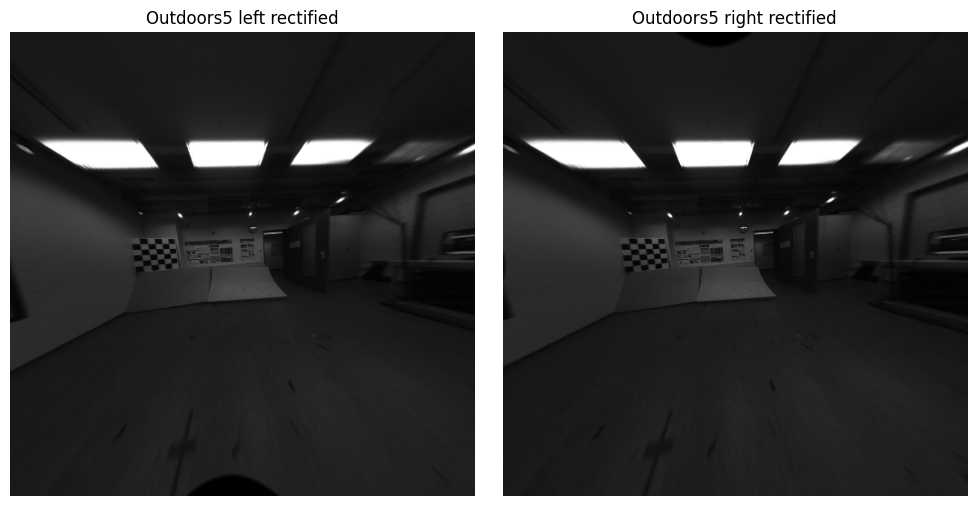

Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_rectification_check.png


In [5]:
imgL_rect, imgR_rect = rectify_stereo_pair(imgL0, imgR0, rectifier)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(imgL_rect, cmap="gray")
axes[0].set_title("Outdoors5 left rectified")
axes[0].axis("off")

axes[1].imshow(imgR_rect, cmap="gray")
axes[1].set_title("Outdoors5 right rectified")
axes[1].axis("off")

plt.tight_layout()

rect_plot_file = PLOT_DIR / "outdoors5_rectification_check.png"
plt.savefig(rect_plot_file, dpi=200)
plt.show()

print("Saved:", rect_plot_file)

## 6. Run Monocular VO baseline

In [6]:
if RUN_MONO:
    print("\n==============================")
    print("Running Monocular VO baseline: Outdoors5")
    print("==============================")

    t0 = time.perf_counter()

    poses_mono, traj_mono, stats_mono = run_monocular_vo(
        left_images=dataset.left_images,
        K=rectifier.K_rect,
        num_frames=num_frames,
        nfeatures=2500,
        ratio=0.75,
        top_k=250,
        ransac_threshold=1.0,
        min_inliers=30,
        rectifier=rectifier,
    )

    mono_runtime = time.perf_counter() - t0
    mono_stats_df = pd.DataFrame(stats_mono)

    print("Monocular VO done")
    print("Frames:", len(poses_mono))
    print("Runtime:", mono_runtime)
    print("Success rate:", 100.0 * mono_stats_df["success"].mean(), "%")
    display(mono_stats_df[["matches", "inliers"]].describe())
else:
    print("RUN_MONO=False, skipping monocular VO.")


Running Monocular VO baseline: Outdoors5
Monocular VO done
Frames: 17747
Runtime: 575.0430580000393
Success rate: 87.2760058604756 %


,matches,inliers
count,17746.000000,17746.000000
mean,247.595233,84.380255
std,13.974476,54.233611
min,38.000000,0.000000
25%,250.000000,45.000000
50%,250.000000,72.000000
75%,250.000000,115.000000
max,250.000000,250.000000


## 7. Run Stereo VO baseline

In [7]:
if RUN_STEREO:
    print("\n==============================")
    print("Running Stereo VO baseline: Outdoors5")
    print("==============================")
    print("Stereo parameters:")
    for k, v in OUTDOORS5_STEREO_PARAMS.items():
        print(f"  {k}: {v}")

    t0 = time.perf_counter()

    try:
        poses_stereo, traj_stereo, stats_stereo, tvec_norms = run_stereo_vo_rectified(
            dataset.left_images,
            dataset.right_images,
            rectifier,
            num_frames=num_frames,
            **OUTDOORS5_STEREO_PARAMS,
        )

    except cv2.error as e:
        print("\nWARNING: Stereo VO crashed in OpenCV. Retrying with use_fundamental=False.")
        print(e)

        OUTDOORS5_STEREO_PARAMS["use_fundamental"] = False

        t0 = time.perf_counter()

        poses_stereo, traj_stereo, stats_stereo, tvec_norms = run_stereo_vo_rectified(
            dataset.left_images,
            dataset.right_images,
            rectifier,
            num_frames=num_frames,
            **OUTDOORS5_STEREO_PARAMS,
        )

    stereo_runtime = time.perf_counter() - t0
    stereo_stats_df = pd.DataFrame(stats_stereo)

    print("Stereo VO done")
    print("Frames:", len(poses_stereo))
    print("Runtime:", stereo_runtime)
    print("Success rate:", 100.0 * stereo_stats_df["success"].mean(), "%")

    cols = ["matches", "corr_3d2d", "inliers", "t_norm", "rot_angle", "reproj_rmse"]
    display(stereo_stats_df[[c for c in cols if c in stereo_stats_df.columns]].describe())
else:
    print("RUN_STEREO=False, skipping stereo VO.")


Running Stereo VO baseline: Outdoors5
Stereo parameters:
  feature_type: orb
  nfeatures: 3000
  ratio: 0.72
  top_k: 300
  cross_check: True
  use_fundamental: False
  max_motion: 120.0
  min_disp: 0.7
  max_depth: 20.0
  min_depth: 0.2
  patch_radius: 2
  min_corr: 30
  min_inliers: 25
  t_norm_min: 0.0003
  t_norm_max: 0.35
  rot_angle_max: 18.0
  use_hybrid: False
  use_wls: True
  max_reprojection_rmse: 3.0
  skip_first_n: 0
  invert_pose_update: True
Stereo VO done
Frames: 17747
Runtime: 1227.6196128999582
Success rate: 96.20759607798941 %


,matches,corr_3d2d,inliers,t_norm,rot_angle,reproj_rmse
count,17746.000000,17746.000000,17746.000000,1.711300e+04,17113.000000,17073.000000
mean,282.475713,172.942071,154.062662,6.290637e-02,1.420662,0.775554
std,45.307937,77.975326,70.741333,3.249658e-02,1.771785,0.148860
min,25.000000,0.000000,0.000000,4.442128e-08,0.000000,0.046336
25%,300.000000,116.000000,103.000000,4.479604e-02,0.605228,0.709202
50%,300.000000,177.000000,159.000000,6.068070e-02,0.909346,0.798180
75%,300.000000,239.000000,213.000000,7.487839e-02,1.336209,0.873845
max,300.000000,300.000000,298.000000,7.580077e-01,13.916728,1.325969


## 8. Load ground truth for evaluation only

In [22]:
from scipy.spatial.transform import Rotation as R, Slerp

raw_calib = load_camchain(DATASET_DIR / "dso" / "camchain.yaml")
T_cam0_imu = get_camera_imu_transform(raw_calib, cam_key="cam0")

gt_ts, gt_cam_poses = load_gt_camera_poses(dataset.gt_file, T_cam0_imu)
image_ts = np.asarray(dataset.timestamps_ns[:num_frames], dtype=np.int64)

def interpolate_gt_poses_to_timestamps(query_ts, gt_ts, gt_poses):
    query_ts = np.asarray(query_ts, dtype=np.int64)
    gt_ts = np.asarray(gt_ts, dtype=np.int64)

    order = np.argsort(gt_ts)
    gt_ts = gt_ts[order]
    gt_poses = [gt_poses[i] for i in order]

    unique_mask = np.ones(len(gt_ts), dtype=bool)
    unique_mask[1:] = gt_ts[1:] != gt_ts[:-1]

    gt_ts = gt_ts[unique_mask]
    gt_poses = [p for p, keep in zip(gt_poses, unique_mask) if keep]

    gt_xyz = np.asarray([T[:3, 3] for T in gt_poses], dtype=np.float64)
    gt_rot = R.from_matrix(np.asarray([T[:3, :3] for T in gt_poses]))

    t0 = gt_ts[0]
    gt_t_sec = (gt_ts - t0) * 1e-9
    q_t_sec = (query_ts - t0) * 1e-9
    q_t_sec = np.clip(q_t_sec, gt_t_sec[0], gt_t_sec[-1])

    interp_xyz = np.column_stack([
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 0]),
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 1]),
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 2]),
    ])

    slerp = Slerp(gt_t_sec, gt_rot)
    interp_rot = slerp(q_t_sec)

    out = []
    for p, rot in zip(interp_xyz, interp_rot):
        T = np.eye(4)
        T[:3, :3] = rot.as_matrix()
        T[:3, 3] = p
        out.append(T)

    return out

def build_gt_valid_index(query_ts, gt_ts, gap_threshold_sec=0.1):
    query_ts = np.asarray(query_ts, dtype=np.int64)
    gt_ts = np.asarray(gt_ts, dtype=np.int64)

    valid_mask = np.ones(len(query_ts), dtype=bool)
    valid_mask &= query_ts >= gt_ts[0]
    valid_mask &= query_ts <= gt_ts[-1]

    gt_gaps = np.diff(gt_ts) * 1e-9
    big_gap_idx = np.where(gt_gaps > gap_threshold_sec)[0]

    for i in big_gap_idx:
        gap_start = gt_ts[i]
        gap_end = gt_ts[i + 1]
        valid_mask &= ~((query_ts >= gap_start) & (query_ts <= gap_end))

    return np.where(valid_mask)[0], big_gap_idx, gt_gaps

def split_contiguous_indices(indices):
    indices = np.asarray(indices, dtype=int)
    if len(indices) == 0:
        return []

    breaks = np.where(np.diff(indices) > 1)[0]
    segments = []
    start = 0

    for b in breaks:
        segments.append(indices[start:b + 1])
        start = b + 1

    segments.append(indices[start:])
    return segments

gt_interp_all = interpolate_gt_poses_to_timestamps(image_ts, gt_ts, gt_cam_poses)
gt_xyz_all = poses_to_xyz(gt_interp_all)

valid_idx, big_gap_idx, gt_gaps = build_gt_valid_index(
    image_ts,
    gt_ts,
    gap_threshold_sec=0.1,
)

valid_segments = split_contiguous_indices(valid_idx)

print("==============================")
print("OUTDOORS5 GT LOADED FOR EVALUATION ONLY")
print("==============================")
print("Image frames:", len(image_ts))
print("GT samples:", len(gt_ts))
print("GT gaps > 0.1 s:", len(big_gap_idx))
print("GT-covered image segments:", len(valid_segments))
print("Segments:", [(int(s[0]), int(s[-1]), len(s)) for s in valid_segments[:10]])

if len(valid_segments) < 1:
    raise RuntimeError("No valid GT-covered segment found.")

OUTDOORS5 GT LOADED FOR EVALUATION ONLY
Image frames: 17747
GT samples: 16480
GT gaps > 0.1 s: 3
GT-covered image segments: 3
Segments: [(0, 1183, 1184), (16174, 16563, 390), (16569, 17746, 1178)]


## 9. Start-end drift evaluation

In [23]:
def path_length_xyz(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)
    if len(xyz) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1)))

def success_stats(stats_df):
    if stats_df is None or len(stats_df) == 0 or "success" not in stats_df.columns:
        return np.nan, np.nan
    success_rate = 100.0 * float(stats_df["success"].mean())
    failure_count = int((~stats_df["success"].astype(bool)).sum())
    return success_rate, failure_count

def evaluate_start_end_protocol(est_xyz_all, method_name, mode="rigid"):
    n = min(len(est_xyz_all), len(gt_xyz_all), len(image_ts))
    segments = [s[s < n] for s in valid_segments if len(s[s < n]) > 5]

    if len(segments) == 1:
        start_idx = segments[0]
        end_idx = segments[0]
        protocol = "single GT-covered segment"
    else:
        start_idx = segments[0]
        end_idx = segments[-1]
        protocol = "start-end drift"

    est_start = est_xyz_all[start_idx]
    gt_start = gt_xyz_all[start_idx]

    if mode == "sim3":
        aligned_start, scale, R_align, t_align = sim3_align(est_start, gt_start)
        alignment = "Sim(3) start segment"
    elif mode == "rigid":
        aligned_start, R_align, t_align = rigid_align_3d(est_start, gt_start)
        scale = 1.0
        alignment = "SE(3) start segment"
    else:
        raise ValueError("mode must be sim3 or rigid")

    est_aligned_all = (scale * (R_align @ est_xyz_all.T)).T + t_align

    start_err = np.linalg.norm(est_aligned_all[start_idx] - gt_xyz_all[start_idx], axis=1)
    end_err = np.linalg.norm(est_aligned_all[end_idx] - gt_xyz_all[end_idx], axis=1)

    vo_start = est_aligned_all[start_idx][0]
    vo_end = est_aligned_all[end_idx][-1]

    gt_start_ref = gt_xyz_all[start_idx][0]
    gt_end_ref = gt_xyz_all[end_idx][-1]

    vo_vec = vo_end - vo_start
    gt_vec = gt_end_ref - gt_start_ref
    drift_vec = vo_vec - gt_vec

    return {
        "dataset": ACTIVE_DATASET,
        "method": method_name,
        "protocol": protocol,
        "alignment": alignment,
        "scale": float(scale),
        "frames_total": int(len(est_xyz_all)),
        "start_eval_frames": int(len(start_idx)),
        "end_eval_frames": int(len(end_idx)),
        "start_rmse_m": float(np.sqrt(np.mean(start_err ** 2))),
        "end_rmse_after_start_align_m": float(np.sqrt(np.mean(end_err ** 2))),
        "final_endpoint_error_m": float(end_err[-1]),
        "drift_x_m": float(drift_vec[0]),
        "drift_y_m": float(drift_vec[1]),
        "drift_z_m": float(drift_vec[2]),
        "xy_drift_m": float(np.linalg.norm(drift_vec[:2])),
        "z_abs_drift_m": float(abs(drift_vec[2])),
        "start_end_drift_m": float(np.linalg.norm(drift_vec)),
        "gt_start_end_distance_m": float(np.linalg.norm(gt_vec)),
        "est_start_end_distance_m": float(np.linalg.norm(vo_vec)),
        "path_length_raw_m": path_length_xyz(est_xyz_all),
        "start_idx": start_idx,
        "end_idx": end_idx,
        "est_aligned_all": est_aligned_all,
        "start_errors": start_err,
        "end_errors": end_err,
    }


summary_rows = []

if RUN_MONO:
    mono_xyz_all = poses_to_xyz(poses_mono)
    mono_eval = evaluate_start_end_protocol(mono_xyz_all, "Monocular VO baseline", mode="sim3")
    mono_success_rate, mono_failure_count = success_stats(mono_stats_df)

    summary_rows.append({
        "dataset": ACTIVE_DATASET,
        "method": "Monocular VO baseline",
        "evaluation_protocol": mono_eval["protocol"],
        "alignment": mono_eval["alignment"],
        "scale": mono_eval["scale"],
        "frames_total": mono_eval["frames_total"],
        "start_eval_frames": mono_eval["start_eval_frames"],
        "end_eval_frames": mono_eval["end_eval_frames"],
        "start_end_drift_m": mono_eval["start_end_drift_m"],
        "xy_drift_m": mono_eval["xy_drift_m"],
        "z_abs_drift_m": mono_eval["z_abs_drift_m"],
        "end_rmse_after_start_align_m": mono_eval["end_rmse_after_start_align_m"],
        "final_endpoint_error_m": mono_eval["final_endpoint_error_m"],
        "path_length_raw_m": mono_eval["path_length_raw_m"],
        "runtime_s": mono_runtime,
        "runtime_per_frame_s": mono_runtime / max(len(poses_mono), 1),
        "success_rate_percent": mono_success_rate,
        "failure_count": mono_failure_count,
    })

if RUN_STEREO:
    stereo_xyz_all = poses_to_xyz(poses_stereo)
    stereo_eval = evaluate_start_end_protocol(stereo_xyz_all, "Stereo VO baseline", mode="rigid")
    stereo_success_rate, stereo_failure_count = success_stats(stereo_stats_df)

    summary_rows.append({
        "dataset": ACTIVE_DATASET,
        "method": "Stereo VO baseline",
        "evaluation_protocol": stereo_eval["protocol"],
        "alignment": stereo_eval["alignment"],
        "scale": stereo_eval["scale"],
        "frames_total": stereo_eval["frames_total"],
        "start_eval_frames": stereo_eval["start_eval_frames"],
        "end_eval_frames": stereo_eval["end_eval_frames"],
        "start_end_drift_m": stereo_eval["start_end_drift_m"],
        "xy_drift_m": stereo_eval["xy_drift_m"],
        "z_abs_drift_m": stereo_eval["z_abs_drift_m"],
        "end_rmse_after_start_align_m": stereo_eval["end_rmse_after_start_align_m"],
        "final_endpoint_error_m": stereo_eval["final_endpoint_error_m"],
        "path_length_raw_m": stereo_eval["path_length_raw_m"],
        "runtime_s": stereo_runtime,
        "runtime_per_frame_s": stereo_runtime / max(len(poses_stereo), 1),
        "success_rate_percent": stereo_success_rate,
        "failure_count": stereo_failure_count,
    })

outdoors5_summary = pd.DataFrame(summary_rows)
display(outdoors5_summary)

,dataset,method,evaluation_protocol,alignment,scale,frames_total,start_eval_frames,end_eval_frames,start_end_drift_m,xy_drift_m,z_abs_drift_m,end_rmse_after_start_align_m,final_endpoint_error_m,path_length_raw_m,runtime_s,runtime_per_frame_s,success_rate_percent,failure_count
0,outdoors5,Monocular VO baseline,start-end drift,Sim(3) start segment,0.003462,17747,1184,1178,2.405969,2.069548,1.227053,2.917108,2.371701,15488.000000,575.043058,0.032402,87.276006,2258
1,outdoors5,Stereo VO baseline,start-end drift,SE(3) start segment,1.000000,17747,1184,1178,32.286558,27.409061,17.063563,32.425621,32.299420,1069.173053,1227.619613,0.069173,96.207596,673


## 10. Evaluation helper for corrected trajectories

The baseline table above uses the official start/end protocol.  
The helper below is used later for optional corrected Stereo VO trajectories, such as the SIFT loop result.  
Ground truth is still used **only for evaluation after the trajectory has already been estimated/corrected**.

In [24]:
# ============================================================
# DEFINE OUTDOORS5 START-END EVALUATION FUNCTION
# ============================================================
# Outdoors5 has GT in separated segments.
# We align using the first GT-covered segment and evaluate drift
# on the last GT-covered segment.
# GT is used ONLY for evaluation.
# ============================================================

import numpy as np

def path_length_xyz(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)
    if len(xyz) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1)))


def rigid_align_3d_umeyama_no_scale(A, B):
    """
    Align A to B using SE(3), no scale.
    Returns R, t, aligned_A.
    """
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)

    mu_A = A.mean(axis=0)
    mu_B = B.mean(axis=0)

    AA = A - mu_A
    BB = B - mu_B

    H = AA.T @ BB

    U, S, Vt = np.linalg.svd(H)
    Rm = Vt.T @ U.T

    if np.linalg.det(Rm) < 0:
        Vt[-1, :] *= -1
        Rm = Vt.T @ U.T

    t = mu_B - Rm @ mu_A

    A_aligned = (Rm @ A.T).T + t

    return Rm, t, A_aligned


def sim3_align_umeyama(A, B):
    """
    Align A to B using Sim(3): scale + rotation + translation.
    Useful for monocular VO.
    Returns scale, R, t, aligned_A.
    """
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)

    mu_A = A.mean(axis=0)
    mu_B = B.mean(axis=0)

    AA = A - mu_A
    BB = B - mu_B

    var_A = np.mean(np.sum(AA ** 2, axis=1))

    H = (AA.T @ BB) / len(A)

    U, S, Vt = np.linalg.svd(H)

    D = np.eye(3)

    if np.linalg.det(Vt.T @ U.T) < 0:
        D[-1, -1] = -1

    Rm = Vt.T @ D @ U.T

    scale = np.trace(np.diag(S) @ D) / max(var_A, 1e-12)

    t = mu_B - scale * (Rm @ mu_A)

    A_aligned = scale * (Rm @ A.T).T + t

    return float(scale), Rm, t, A_aligned


def apply_alignment_xyz(xyz, scale, Rm, t):
    xyz = np.asarray(xyz, dtype=np.float64)
    return scale * (Rm @ xyz.T).T + t


def evaluate_outdoors5_start_end(est_xyz, method_name="VO", alignment="se3"):
    """
    Evaluate Outdoors5 using start/end GT segments.

    Required variables already in notebook:
    - gt_xyz_all
    - valid_segments OR start_idx/end_idx

    Returns a dictionary compatible with plotting/filtering cells.
    """
    est_xyz = np.asarray(est_xyz, dtype=np.float64)

    if "valid_segments" in globals() and len(valid_segments) >= 2:
        sidx = np.asarray(valid_segments[0], dtype=int)
        eidx = np.asarray(valid_segments[-1], dtype=int)
    elif "start_idx" in globals() and "end_idx" in globals():
        sidx = np.asarray(start_idx, dtype=int)
        eidx = np.asarray(end_idx, dtype=int)
    else:
        raise NameError(
            "Need valid_segments or start_idx/end_idx before evaluation."
        )

    # Keep only indices available in estimated trajectory and GT
    max_len = min(len(est_xyz), len(gt_xyz_all))
    sidx = sidx[sidx < max_len]
    eidx = eidx[eidx < max_len]

    if len(sidx) < 5 or len(eidx) < 5:
        raise RuntimeError(
            f"Not enough start/end GT frames. start={len(sidx)}, end={len(eidx)}"
        )

    gt_start = gt_xyz_all[sidx]
    gt_end = gt_xyz_all[eidx]

    est_start = est_xyz[sidx]
    est_end = est_xyz[eidx]

    alignment_lower = alignment.lower()

    if alignment_lower in ["sim3", "similarity"]:
        scale, Rm, t, est_start_aligned = sim3_align_umeyama(est_start, gt_start)
        est_aligned_full = apply_alignment_xyz(est_xyz, scale, Rm, t)
        alignment_name = "Sim(3) start segment"

    else:
        Rm, t, est_start_aligned = rigid_align_3d_umeyama_no_scale(est_start, gt_start)
        scale = 1.0
        est_aligned_full = apply_alignment_xyz(est_xyz, scale, Rm, t)
        alignment_name = "SE(3) start segment"

    est_end_aligned = est_aligned_full[eidx]

    start_err = np.linalg.norm(est_start_aligned - gt_start, axis=1)
    end_err = np.linalg.norm(est_end_aligned - gt_end, axis=1)

    # Start-end displacement comparison
    gt_start_ref = gt_start[0]
    gt_end_ref = gt_end[-1]

    est_start_ref = est_aligned_full[sidx[0]]
    est_end_ref = est_aligned_full[eidx[-1]]

    gt_vec = gt_end_ref - gt_start_ref
    est_vec = est_end_ref - est_start_ref

    drift_vec = est_vec - gt_vec

    out = {
        "dataset": "outdoors5",
        "method": method_name,
        "evaluation_protocol": "start-end drift",
        "alignment": alignment_name,
        "scale": scale,

        "frames_total": int(len(est_xyz)),
        "start_eval_frames": int(len(sidx)),
        "end_eval_frames": int(len(eidx)),

        "start_rmse_m": float(np.sqrt(np.mean(start_err ** 2))),
        "end_rmse_after_start_align_m": float(np.sqrt(np.mean(end_err ** 2))),
        "final_endpoint_error_m": float(np.linalg.norm(est_end_ref - gt_end_ref)),

        "drift_x_m": float(drift_vec[0]),
        "drift_y_m": float(drift_vec[1]),
        "drift_z_m": float(drift_vec[2]),

        "xy_drift_m": float(np.linalg.norm(drift_vec[:2])),
        "z_abs_drift_m": float(abs(drift_vec[2])),
        "start_end_drift_m": float(np.linalg.norm(drift_vec)),

        "path_length_est_raw_m": path_length_xyz(est_xyz),

        "est_aligned_full": est_aligned_full,
        "start_idx": sidx,
        "end_idx": eidx,
        "start_error": start_err,
        "end_error": end_err,
    }

    return out


print("evaluate_outdoors5_start_end is now defined.")

evaluate_outdoors5_start_end is now defined.


## 11. Baseline plots for required report figures

These figures show the required Outdoors5 baseline results: raw Monocular VO, raw Stereo VO, start/end GT-covered segments, end-segment error, and drift components.

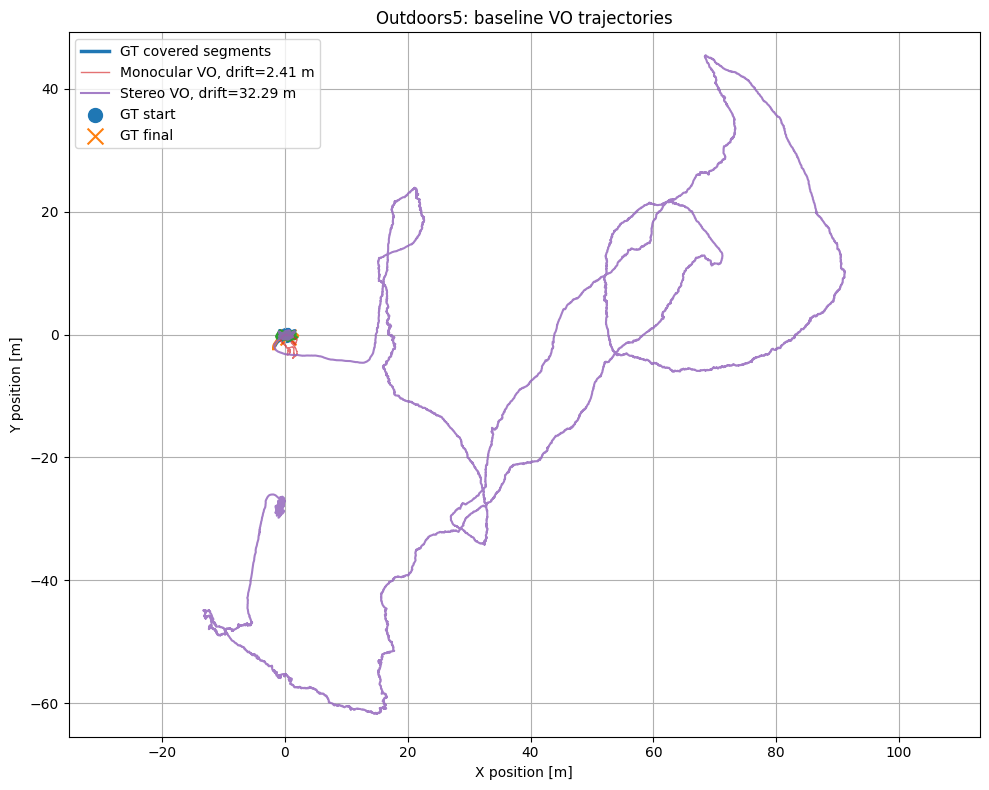

Saved trajectory plot: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_trajectory_start_end_gt.png


In [25]:
plt.figure(figsize=(10, 8))

for i, seg in enumerate(valid_segments):
    if len(seg) < 2:
        continue
    label = "GT covered segments" if i == 0 else None
    plt.plot(gt_xyz_all[seg, 0], gt_xyz_all[seg, 1], linewidth=2.5, label=label)

if RUN_MONO:
    plt.plot(
        mono_eval["est_aligned_all"][:, 0],
        mono_eval["est_aligned_all"][:, 1],
        linewidth=1.0,
        alpha=0.65,
        label=f"Monocular VO, drift={mono_eval['start_end_drift_m']:.2f} m",
    )

if RUN_STEREO:
    plt.plot(
        stereo_eval["est_aligned_all"][:, 0],
        stereo_eval["est_aligned_all"][:, 1],
        linewidth=1.5,
        alpha=0.85,
        label=f"Stereo VO, drift={stereo_eval['start_end_drift_m']:.2f} m",
    )

start_frame = valid_segments[0][0]
end_frame = valid_segments[-1][-1]

plt.scatter(gt_xyz_all[start_frame, 0], gt_xyz_all[start_frame, 1], s=100, marker="o", label="GT start")
plt.scatter(gt_xyz_all[end_frame, 0], gt_xyz_all[end_frame, 1], s=130, marker="x", label="GT final")

plt.xlabel("X position [m]")
plt.ylabel("Y position [m]")
plt.title("Outdoors5: baseline VO trajectories")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()

trajectory_plot_file = PLOT_DIR / "outdoors5_trajectory_start_end_gt.png"
plt.savefig(trajectory_plot_file, dpi=200)
plt.show()

print("Saved trajectory plot:", trajectory_plot_file)

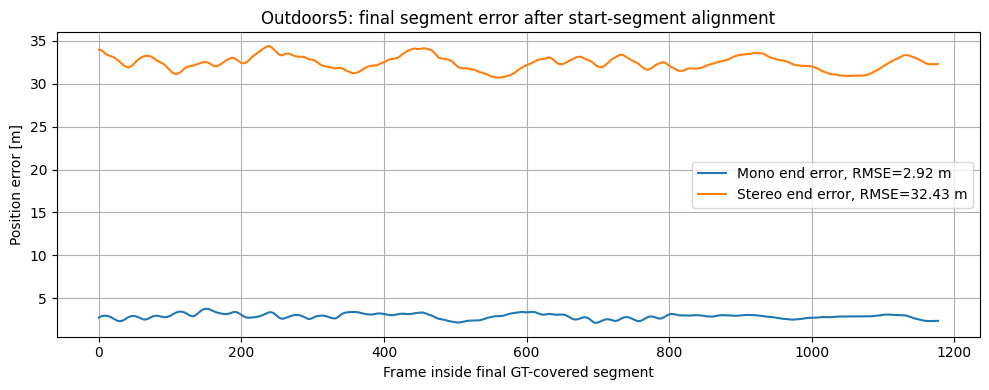

Saved end-segment error plot: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_end_segment_error.png


In [26]:
plt.figure(figsize=(10, 4))

if RUN_MONO:
    plt.plot(mono_eval["end_errors"], label=f"Mono end error, RMSE={mono_eval['end_rmse_after_start_align_m']:.2f} m")

if RUN_STEREO:
    plt.plot(stereo_eval["end_errors"], label=f"Stereo end error, RMSE={stereo_eval['end_rmse_after_start_align_m']:.2f} m")

plt.xlabel("Frame inside final GT-covered segment")
plt.ylabel("Position error [m]")
plt.title("Outdoors5: final segment error after start-segment alignment")
plt.grid(True)
plt.legend()
plt.tight_layout()

error_plot_file = PLOT_DIR / "outdoors5_end_segment_error.png"
plt.savefig(error_plot_file, dpi=200)
plt.show()

print("Saved end-segment error plot:", error_plot_file)

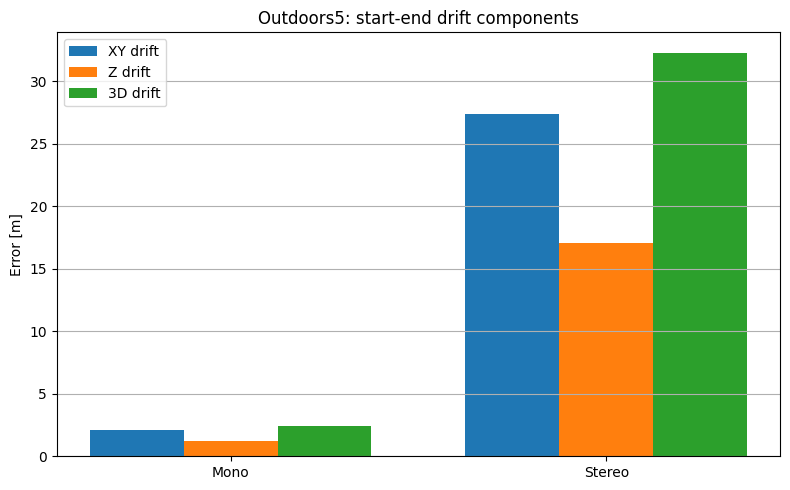

Saved drift component plot: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_drift_components.png


In [27]:
plot_rows = []

if RUN_MONO:
    plot_rows.append(("Mono", mono_eval["xy_drift_m"], mono_eval["z_abs_drift_m"], mono_eval["start_end_drift_m"]))

if RUN_STEREO:
    plot_rows.append(("Stereo", stereo_eval["xy_drift_m"], stereo_eval["z_abs_drift_m"], stereo_eval["start_end_drift_m"]))

labels = [r[0] for r in plot_rows]
xy_vals = [r[1] for r in plot_rows]
z_vals = [r[2] for r in plot_rows]
total_vals = [r[3] for r in plot_rows]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, xy_vals, width, label="XY drift")
plt.bar(x, z_vals, width, label="Z drift")
plt.bar(x + width, total_vals, width, label="3D drift")

plt.xticks(x, labels)
plt.ylabel("Error [m]")
plt.title("Outdoors5: start-end drift components")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()

drift_plot_file = PLOT_DIR / "outdoors5_drift_components.png"
plt.savefig(drift_plot_file, dpi=200)
plt.show()

print("Saved drift component plot:", drift_plot_file)

## 12. Optional Stereo VO improvement: SIFT visual loop closure

The raw Stereo VO baseline is kept unchanged.  
This section tests a classical, non-deep-learning improvement using a visually verified loop.  
The accepted loop is `6000 → 11847`.

Important: false loop candidates are not used. The loop is accepted only after visual inspection and dense stereo-PnP verification.

### 12.1 Loop-closure utility functions

These utilities load rectified frames, extract loop features, compute dense disparity for loop verification, estimate a loop transform with PnP, and apply a position-only loop correction.

In [28]:
# ============================================================
# OUTDOORS5 ONE-LOOP VISUAL CLOSURE UTILITIES
# ============================================================
# GT is NOT used for loop detection/correction.
# GT is used only after correction for evaluation.
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Camera matrix from rectifier
# ------------------------------------------------------------
if hasattr(rectifier, "K_rect"):
    K_rect = np.asarray(rectifier.K_rect, dtype=np.float64)
else:
    K_rect = np.array([
        [float(rectifier.fx), 0.0, float(rectifier.cx)],
        [0.0, float(rectifier.fy), float(rectifier.cy)],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

fx = float(K_rect[0, 0])
fy = float(K_rect[1, 1])
cx = float(K_rect[0, 2])
cy = float(K_rect[1, 2])
baseline = float(rectifier.baseline)

dist_rect = None

# ------------------------------------------------------------
# ORB detector for loop search
# ------------------------------------------------------------
loop_orb = cv2.ORB_create(
    nfeatures=5000,
    scaleFactor=1.2,
    nlevels=8,
    fastThreshold=7,
)

loop_bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

OUTDOORS5_LOOP_CACHE = {}
OUTDOORS5_DISP_CACHE = {}

def rotation_angle_deg(Rm):
    v = (np.trace(Rm) - 1.0) / 2.0
    v = np.clip(v, -1.0, 1.0)
    return float(np.degrees(np.arccos(v)))

def se3_inv(T):
    Ti = np.eye(4, dtype=np.float64)
    Rm = T[:3, :3]
    t = T[:3, 3]
    Ti[:3, :3] = Rm.T
    Ti[:3, 3] = -Rm.T @ t
    return Ti

def poses_to_xyz_safe(poses):
    poses = np.asarray(poses)
    if poses.ndim == 3:
        return poses[:, :3, 3].copy()
    if poses.ndim == 2 and poses.shape[1] == 3:
        return poses.copy()
    raise ValueError(f"Unsupported pose shape: {poses.shape}")

def path_length_xyz_safe(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)
    if len(xyz) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1)))

def load_rectified_pair_loop(i):
    i = int(i)

    imgL_raw = cv2.imread(str(dataset.left_images[i]), cv2.IMREAD_GRAYSCALE)
    imgR_raw = cv2.imread(str(dataset.right_images[i]), cv2.IMREAD_GRAYSCALE)

    if imgL_raw is None:
        raise FileNotFoundError(dataset.left_images[i])
    if imgR_raw is None:
        raise FileNotFoundError(dataset.right_images[i])

    imgL, imgR = rectify_stereo_pair(imgL_raw, imgR_raw, rectifier)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    imgL = clahe.apply(imgL)
    imgR = clahe.apply(imgR)

    return imgL, imgR

def extract_loop_features(i):
    i = int(i)

    if i in OUTDOORS5_LOOP_CACHE:
        return OUTDOORS5_LOOP_CACHE[i]

    imgL, imgR = load_rectified_pair_loop(i)

    kp, des = loop_orb.detectAndCompute(imgL, None)

    feat = {
        "imgL": imgL,
        "imgR": imgR,
        "kp": kp,
        "des": des,
    }

    OUTDOORS5_LOOP_CACHE[i] = feat
    return feat

def ratio_match_orb(des1, des2, ratio=0.75):
    if des1 is None or des2 is None:
        return []

    des1 = np.asarray(des1, dtype=np.uint8)
    des2 = np.asarray(des2, dtype=np.uint8)

    if len(des1) < 2 or len(des2) < 2:
        return []

    des1 = np.ascontiguousarray(des1)
    des2 = np.ascontiguousarray(des2)

    try:
        knn = loop_bf.knnMatch(des1, des2, k=2)
    except cv2.error:
        return []

    good = []

    for pair in knn:
        if len(pair) < 2:
            continue

        m, n = pair

        if m.distance < ratio * n.distance:
            good.append(m)

    return sorted(good, key=lambda m: m.distance)

def visual_loop_score(old_idx, new_idx, min_raw=25, min_f_inliers=18, min_f_ratio=0.35):
    feat_old = extract_loop_features(old_idx)
    feat_new = extract_loop_features(new_idx)

    kp_old = feat_old["kp"]
    des_old = feat_old["des"]
    kp_new = feat_new["kp"]
    des_new = feat_new["des"]

    matches = ratio_match_orb(des_old, des_new, ratio=0.75)

    row = {
        "old_idx": int(old_idx),
        "new_idx": int(new_idx),
        "kp_old": len(kp_old) if kp_old is not None else 0,
        "kp_new": len(kp_new) if kp_new is not None else 0,
        "raw_matches": len(matches),
        "F_inliers": 0,
        "F_ratio": 0.0,
        "same_place_candidate": False,
        "score": -999.0,
    }

    if len(matches) < min_raw:
        return row

    pts_old = np.float32([kp_old[m.queryIdx].pt for m in matches])
    pts_new = np.float32([kp_new[m.trainIdx].pt for m in matches])

    try:
        F, mask = cv2.findFundamentalMat(
            pts_old,
            pts_new,
            cv2.FM_RANSAC,
            ransacReprojThreshold=1.5,
            confidence=0.999,
            maxIters=2000,
        )
    except cv2.error:
        return row

    if F is None or mask is None:
        return row

    mask = mask.ravel().astype(bool)
    f_inliers = int(mask.sum())
    f_ratio = float(f_inliers / max(len(matches), 1))

    row["F_inliers"] = f_inliers
    row["F_ratio"] = f_ratio

    if f_inliers >= min_f_inliers and f_ratio >= min_f_ratio:
        row["same_place_candidate"] = True
        row["score"] = float(f_inliers * f_ratio)

    return row

def compute_dense_disparity_for_loop(frame_idx):
    frame_idx = int(frame_idx)

    if frame_idx in OUTDOORS5_DISP_CACHE:
        return OUTDOORS5_DISP_CACHE[frame_idx]

    imgL, imgR = load_rectified_pair_loop(frame_idx)

    matcher = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=128,
        blockSize=3,
        P1=8 * 3 * 3 * 3,
        P2=32 * 3 * 3 * 3,
        disp12MaxDiff=1,
        uniquenessRatio=8,
        speckleWindowSize=80,
        speckleRange=16,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
    )

    disp = matcher.compute(imgL, imgR).astype(np.float32) / 16.0
    disp[disp < 0.7] = np.nan

    OUTDOORS5_DISP_CACHE[frame_idx] = disp
    return disp

def estimate_loop_pnp_dense_outdoors5(
    old_idx,
    new_idx,
    min_corr=16,
    min_inliers=10,
    max_depth=25.0,
    min_depth=0.3,
    max_rmse_px=3.0,
):
    feat_old = extract_loop_features(old_idx)
    feat_new = extract_loop_features(new_idx)

    kp_old = feat_old["kp"]
    des_old = feat_old["des"]
    kp_new = feat_new["kp"]
    des_new = feat_new["des"]

    matches = ratio_match_orb(des_old, des_new, ratio=0.75)

    stats = {
        "reason": "INIT",
        "raw_matches": len(matches),
        "F_inliers": 0,
        "F_ratio": 0.0,
        "corr": 0,
        "inliers": 0,
        "rmse_px": np.nan,
        "t_norm_m": np.nan,
        "rot_deg": np.nan,
    }

    if len(matches) < 12:
        stats["reason"] = "LOW_RAW_MATCHES"
        return None, stats

    pts_old = np.float32([kp_old[m.queryIdx].pt for m in matches])
    pts_new = np.float32([kp_new[m.trainIdx].pt for m in matches])

    try:
        F, mask = cv2.findFundamentalMat(
            pts_old,
            pts_new,
            cv2.FM_RANSAC,
            ransacReprojThreshold=1.5,
            confidence=0.999,
            maxIters=2000,
        )
    except cv2.error:
        stats["reason"] = "F_CRASH"
        return None, stats

    if F is not None and mask is not None:
        mask = mask.ravel().astype(bool)
        stats["F_inliers"] = int(mask.sum())
        stats["F_ratio"] = float(mask.sum() / max(len(matches), 1))
        matches = [m for m, keep in zip(matches, mask) if keep]

    disp_old = compute_dense_disparity_for_loop(old_idx)

    h, w = disp_old.shape

    obj_pts = []
    img_pts = []

    patch_radius = 2

    for m in matches:
        u, v = kp_old[m.queryIdx].pt
        u_i = int(round(u))
        v_i = int(round(v))

        if u_i < 0 or u_i >= w or v_i < 0 or v_i >= h:
            continue

        x0 = max(0, u_i - patch_radius)
        x1 = min(w, u_i + patch_radius + 1)
        y0 = max(0, v_i - patch_radius)
        y1 = min(h, v_i + patch_radius + 1)

        patch = disp_old[y0:y1, x0:x1]
        valid = patch[np.isfinite(patch) & (patch >= 0.7)]

        if len(valid) < 3:
            continue

        d = float(np.median(valid))
        Z = fx * baseline / d

        if not np.isfinite(Z) or Z < min_depth or Z > max_depth:
            continue

        X = (u - cx) * Z / fx
        Y = (v - cy) * Z / fy

        obj_pts.append([X, Y, Z])
        img_pts.append(kp_new[m.trainIdx].pt)

    obj_pts = np.asarray(obj_pts, dtype=np.float32)
    img_pts = np.asarray(img_pts, dtype=np.float32)

    stats["corr"] = int(len(obj_pts))

    if len(obj_pts) < min_corr:
        stats["reason"] = "LOW_3D2D"
        return None, stats

    ok, rvec, tvec, inliers = cv2.solvePnPRansac(
        obj_pts,
        img_pts,
        K_rect,
        dist_rect,
        iterationsCount=1000,
        reprojectionError=3.0,
        confidence=0.999,
        flags=cv2.SOLVEPNP_EPNP,
    )

    if not ok or inliers is None:
        stats["reason"] = "PNP_FAIL"
        return None, stats

    inliers = inliers.ravel()

    if len(inliers) < min_inliers:
        stats["reason"] = "LOW_INLIERS"
        stats["inliers"] = int(len(inliers))
        return None, stats

    ok2, rvec, tvec = cv2.solvePnP(
        obj_pts[inliers],
        img_pts[inliers],
        K_rect,
        dist_rect,
        rvec,
        tvec,
        useExtrinsicGuess=True,
        flags=cv2.SOLVEPNP_ITERATIVE,
    )

    if not ok2:
        stats["reason"] = "REFINE_FAIL"
        return None, stats

    R_loop, _ = cv2.Rodrigues(rvec)

    proj, _ = cv2.projectPoints(
        obj_pts[inliers],
        rvec,
        tvec,
        K_rect,
        dist_rect,
    )

    proj = proj.reshape(-1, 2)
    err = np.linalg.norm(proj - img_pts[inliers], axis=1)
    rmse = float(np.sqrt(np.mean(err ** 2)))

    if rmse > max_rmse_px:
        stats["reason"] = "HIGH_RMSE"
        stats["inliers"] = int(len(inliers))
        stats["rmse_px"] = rmse
        return None, stats

    T_new_old = np.eye(4, dtype=np.float64)
    T_new_old[:3, :3] = R_loop
    T_new_old[:3, 3] = tvec.ravel()

    stats["reason"] = "OK"
    stats["inliers"] = int(len(inliers))
    stats["rmse_px"] = rmse
    stats["t_norm_m"] = float(np.linalg.norm(tvec))
    stats["rot_deg"] = rotation_angle_deg(R_loop)

    return T_new_old, stats

def apply_one_loop_position_correction(poses_input, old_idx, new_idx, T_new_old_loop):
    poses_corr = np.asarray(poses_input, dtype=np.float64).copy()

    T_w_old = poses_corr[old_idx]
    T_w_new_raw = poses_corr[new_idx]

    # Same convention as corridor notebook
    T_w_new_expected = T_w_old @ se3_inv(T_new_old_loop)

    p_raw = T_w_new_raw[:3, 3]
    p_expected = T_w_new_expected[:3, 3]

    delta = p_expected - p_raw

    for i in range(old_idx, len(poses_corr)):
        if i <= new_idx:
            alpha = (i - old_idx) / max(new_idx - old_idx, 1)
        else:
            alpha = 1.0

        poses_corr[i, :3, 3] += alpha * delta

    return poses_corr, delta

print("Outdoors5 one-loop utilities ready.")

Outdoors5 one-loop utilities ready.


### 12.2 SIFT rotation-compensated loop search

This searches for repeated visual places using SIFT/RootSIFT features and rotations of the candidate frame.  
It does not use ground truth.

In [29]:
# ============================================================
# OUTDOORS5: SIFT + ROTATION-COMPENSATED LOOP SEARCH
# ============================================================
# Purpose:
# Find loop candidates in difficult/repetitive texture.
#
# Method:
# - SIFT/RootSIFT features
# - test rotations of the new image: 0, 90, 180, 270 degrees
# - mutual ratio matching
# - Fundamental matrix verification
# - Homography verification
#
# GT is NOT used.
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
if "dataset" not in globals():
    raise NameError("dataset is missing.")

if "rectifier" not in globals():
    raise NameError("rectifier is missing.")

if "rectify_stereo_pair" not in globals():
    raise NameError("rectify_stereo_pair is missing.")

if "TABLE_DIR" not in globals():
    TABLE_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables")
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

if "PLOT_DIR" not in globals():
    PLOT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# SIFT detector
# ------------------------------------------------------------
sift_loop = cv2.SIFT_create(
    nfeatures=7000,
    contrastThreshold=0.01,
    edgeThreshold=10,
    sigma=1.6,
)

sift_bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

SIFT_LOOP_CACHE = {}

def load_rectified_left_for_loop(i):
    i = int(i)

    imgL_raw = cv2.imread(str(dataset.left_images[i]), cv2.IMREAD_GRAYSCALE)
    imgR_raw = cv2.imread(str(dataset.right_images[i]), cv2.IMREAD_GRAYSCALE)

    if imgL_raw is None:
        raise FileNotFoundError(dataset.left_images[i])
    if imgR_raw is None:
        raise FileNotFoundError(dataset.right_images[i])

    imgL, imgR = rectify_stereo_pair(imgL_raw, imgR_raw, rectifier)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    imgL = clahe.apply(imgL)

    return imgL

def rotate_image(img, rot):
    if rot == 0:
        return img.copy()
    if rot == 90:
        return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    if rot == 180:
        return cv2.rotate(img, cv2.ROTATE_180)
    if rot == 270:
        return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    raise ValueError("rot must be 0, 90, 180, or 270")

def map_rotated_points_to_original(pts_rot, rot, h, w):
    """
    Map keypoints from rotated image coordinates back to original image coordinates.
    """
    pts_rot = np.asarray(pts_rot, dtype=np.float32)
    x = pts_rot[:, 0]
    y = pts_rot[:, 1]

    if rot == 0:
        x0 = x
        y0 = y

    elif rot == 90:
        # original -> rotated clockwise: xr = h - 1 - y0, yr = x0
        x0 = y
        y0 = h - 1 - x

    elif rot == 180:
        x0 = w - 1 - x
        y0 = h - 1 - y

    elif rot == 270:
        # original -> rotated ccw: xr = y0, yr = w - 1 - x0
        x0 = w - 1 - y
        y0 = x

    else:
        raise ValueError("rot must be 0, 90, 180, or 270")

    return np.column_stack([x0, y0]).astype(np.float32)

def rootsift(desc):
    if desc is None:
        return None

    desc = desc.astype(np.float32)
    desc /= (np.sum(desc, axis=1, keepdims=True) + 1e-12)
    desc = np.sqrt(desc)
    desc /= (np.linalg.norm(desc, axis=1, keepdims=True) + 1e-12)

    return desc.astype(np.float32)

def extract_sift_loop_features(frame_idx, rot=0):
    key = (int(frame_idx), int(rot))

    if key in SIFT_LOOP_CACHE:
        return SIFT_LOOP_CACHE[key]

    img_orig = load_rectified_left_for_loop(frame_idx)
    h, w = img_orig.shape[:2]

    img_rot = rotate_image(img_orig, rot)

    kp, des = sift_loop.detectAndCompute(img_rot, None)
    des = rootsift(des)

    if kp is None:
        kp = []

    pts_rot = np.float32([k.pt for k in kp]) if len(kp) > 0 else np.empty((0, 2), dtype=np.float32)
    pts_orig = map_rotated_points_to_original(pts_rot, rot, h, w) if len(pts_rot) > 0 else pts_rot

    feat = {
        "frame": int(frame_idx),
        "rot": int(rot),
        "img_orig": img_orig,
        "img_rot": img_rot,
        "kp": kp,
        "des": des,
        "pts_orig": pts_orig,
    }

    SIFT_LOOP_CACHE[key] = feat
    return feat

def mutual_ratio_sift(desA, desB, ratio=0.75):
    if desA is None or desB is None:
        return []

    if len(desA) < 2 or len(desB) < 2:
        return []

    desA = np.ascontiguousarray(desA.astype(np.float32))
    desB = np.ascontiguousarray(desB.astype(np.float32))

    knn_ab = sift_bf.knnMatch(desA, desB, k=2)
    knn_ba = sift_bf.knnMatch(desB, desA, k=2)

    good_ab = {}

    for pair in knn_ab:
        if len(pair) < 2:
            continue

        m, n = pair

        if m.distance < ratio * n.distance:
            good_ab[m.queryIdx] = m

    good_ba = {}

    for pair in knn_ba:
        if len(pair) < 2:
            continue

        m, n = pair

        if m.distance < ratio * n.distance:
            good_ba[m.queryIdx] = m

    mutual = []

    for qA, mAB in good_ab.items():
        qB = mAB.trainIdx

        if qB in good_ba:
            mBA = good_ba[qB]

            if mBA.trainIdx == qA:
                mutual.append(mAB)

    return sorted(mutual, key=lambda m: m.distance)

def sift_rotated_loop_score(old_idx, new_idx, new_rot):
    old_feat = extract_sift_loop_features(old_idx, rot=0)
    new_feat = extract_sift_loop_features(new_idx, rot=new_rot)

    kp_old = old_feat["kp"]
    kp_new = new_feat["kp"]

    des_old = old_feat["des"]
    des_new = new_feat["des"]

    matches = mutual_ratio_sift(des_old, des_new, ratio=0.78)

    row = {
        "old_idx": int(old_idx),
        "new_idx": int(new_idx),
        "new_rotation_deg": int(new_rot),
        "kp_old": len(kp_old),
        "kp_new": len(kp_new),
        "raw_matches": len(matches),
        "F_inliers": 0,
        "F_ratio": 0.0,
        "H_inliers": 0,
        "H_ratio": 0.0,
        "candidate": False,
        "score": -999.0,
    }

    if len(matches) < 25:
        return row

    pts_old = np.float32([old_feat["pts_orig"][m.queryIdx] for m in matches])
    pts_new = np.float32([new_feat["pts_orig"][m.trainIdx] for m in matches])

    # Fundamental verification
    try:
        F, F_mask = cv2.findFundamentalMat(
            pts_old,
            pts_new,
            cv2.FM_RANSAC,
            ransacReprojThreshold=1.5,
            confidence=0.999,
            maxIters=3000,
        )
    except cv2.error:
        F, F_mask = None, None

    if F_mask is not None:
        F_mask = F_mask.ravel().astype(bool)
        F_in = int(F_mask.sum())
    else:
        F_mask = np.zeros(len(matches), dtype=bool)
        F_in = 0

    F_ratio = F_in / max(len(matches), 1)

    # Homography verification, useful for planar/repeated texture
    try:
        H, H_mask = cv2.findHomography(
            pts_old,
            pts_new,
            cv2.RANSAC,
            ransacReprojThreshold=4.0,
            maxIters=3000,
            confidence=0.999,
        )
    except cv2.error:
        H, H_mask = None, None

    if H_mask is not None:
        H_mask = H_mask.ravel().astype(bool)
        H_in = int(H_mask.sum())
    else:
        H_in = 0

    H_ratio = H_in / max(len(matches), 1)

    row["F_inliers"] = F_in
    row["F_ratio"] = F_ratio
    row["H_inliers"] = H_in
    row["H_ratio"] = H_ratio

    # Strong visual condition
    if (
        len(matches) >= 35
        and F_in >= 18
        and F_ratio >= 0.35
        and H_in >= 15
    ):
        row["candidate"] = True
        row["score"] = float(F_in * F_ratio + 0.5 * H_in * H_ratio)

    return row

# ------------------------------------------------------------
# Search grid
# ------------------------------------------------------------
if "stereo_poses" in globals():
    n_frames = len(stereo_poses)
elif "poses_stereo" in globals():
    n_frames = len(poses_stereo)
else:
    n_frames = len(dataset.left_images)

old_candidates = np.unique(np.r_[
    np.arange(0, min(6500, n_frames - 1), 200),
    [700, 800, 1000, 1600, 1700, 2100, 2400, 2600, 2900, 3300, 5000, 5500]
]).astype(int)

new_candidates = np.unique(np.r_[
    np.arange(max(11000, n_frames - 6500), n_frames, 200),
    [12747, 14996, 15413, 15996, 16329, 16496, 16746, 16829, 17412, 17579, n_frames - 1]
]).astype(int)

old_candidates = old_candidates[(old_candidates >= 0) & (old_candidates < n_frames)]
new_candidates = new_candidates[(new_candidates >= 0) & (new_candidates < n_frames)]

rotations = [0, 90, 180, 270]

print("old candidates:", old_candidates[0], "->", old_candidates[-1], "count:", len(old_candidates))
print("new candidates:", new_candidates[0], "->", new_candidates[-1], "count:", len(new_candidates))
print("rotations:", rotations)

rows = []
counter = 0
total = len(old_candidates) * len(new_candidates) * len(rotations)

for old_idx in old_candidates:
    for new_idx in new_candidates:
        if new_idx <= old_idx + 1000:
            continue

        for rot in rotations:
            counter += 1

            row = sift_rotated_loop_score(int(old_idx), int(new_idx), int(rot))

            if row["candidate"]:
                rows.append(row)

            if counter % 500 == 0:
                print("searched", counter, "/", total, "candidates:", len(rows))

outdoors5_sift_loop_df = pd.DataFrame(rows)

if len(outdoors5_sift_loop_df) == 0:
    print("No SIFT rotation loop candidates found.")
else:
    outdoors5_sift_loop_df = outdoors5_sift_loop_df.sort_values(
        ["score", "F_inliers", "H_inliers"],
        ascending=False
    )

    display(outdoors5_sift_loop_df.head(30))

    sift_loop_path = TABLE_DIR / "outdoors5_sift_rotation_loop_candidates.csv"
    outdoors5_sift_loop_df.to_csv(sift_loop_path, index=False)
    print("Saved:", sift_loop_path)

old candidates: 0 -> 6400 count: 39
new candidates: 11247 -> 17746 count: 44
rotations: [0, 90, 180, 270]
searched 500 / 6864 candidates: 0
searched 1000 / 6864 candidates: 0
searched 1500 / 6864 candidates: 0
searched 2000 / 6864 candidates: 0
searched 2500 / 6864 candidates: 0
searched 3000 / 6864 candidates: 0
searched 3500 / 6864 candidates: 0
searched 4000 / 6864 candidates: 0
searched 4500 / 6864 candidates: 0
searched 5000 / 6864 candidates: 0
searched 5500 / 6864 candidates: 0
searched 6000 / 6864 candidates: 7
searched 6500 / 6864 candidates: 11


,old_idx,new_idx,new_rotation_deg,kp_old,kp_new,raw_matches,F_inliers,F_ratio,H_inliers,H_ratio,candidate,score
9,6000,11847,180,948,1134,49,39,0.795918,28,0.571429,True,39.040816
5,5600,11447,90,850,1083,38,31,0.815789,28,0.736842,True,35.605263
6,5600,11447,270,850,1075,39,30,0.769231,29,0.743590,True,33.858974
8,6000,11847,90,948,1133,49,36,0.734694,25,0.510204,True,32.826531
4,5600,11447,0,850,1067,37,28,0.756757,27,0.729730,True,31.040541
1,5400,11247,90,791,1024,43,32,0.744186,22,0.511628,True,29.441860
10,6000,11847,270,948,1163,43,31,0.720930,23,0.534884,True,28.500000
7,6000,11847,0,948,1146,43,30,0.697674,24,0.558140,True,27.627907
2,5400,11247,180,791,1032,46,31,0.673913,23,0.500000,True,26.641304
3,5400,11247,270,791,1038,43,29,0.674419,22,0.511628,True,25.186047


Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_sift_rotation_loop_candidates.csv


### 12.3 Dense stereo-PnP verification of SIFT candidates

This step verifies the SIFT visual candidates using dense-stereo 3D points and PnP.  
Only geometrically plausible loops are kept.

In [30]:
# ============================================================
# OUTDOORS5: VERIFY SIFT ROTATION CANDIDATES WITH DENSE PNP
# ============================================================

if "outdoors5_sift_loop_df" not in globals() or len(outdoors5_sift_loop_df) == 0:
    raise RuntimeError("No SIFT loop candidates found. Run previous cell first.")

if "stereo_poses" in globals():
    stereo_pose_source = stereo_poses
elif "poses_stereo" in globals():
    stereo_pose_source = poses_stereo
else:
    raise NameError("Need stereo_poses or poses_stereo.")

# Camera params
if hasattr(rectifier, "K_rect"):
    K_rect = np.asarray(rectifier.K_rect, dtype=np.float64)
else:
    K_rect = np.array([
        [float(rectifier.fx), 0, float(rectifier.cx)],
        [0, float(rectifier.fy), float(rectifier.cy)],
        [0, 0, 1],
    ], dtype=np.float64)

fx = float(K_rect[0, 0])
fy = float(K_rect[1, 1])
cx = float(K_rect[0, 2])
cy = float(K_rect[1, 2])
baseline = float(rectifier.baseline)
dist_rect = None

DENSE_DISP_CACHE_SIFT = {}

def compute_dense_disparity_sift_loop(frame_idx):
    frame_idx = int(frame_idx)

    if frame_idx in DENSE_DISP_CACHE_SIFT:
        return DENSE_DISP_CACHE_SIFT[frame_idx]

    imgL_raw = cv2.imread(str(dataset.left_images[frame_idx]), cv2.IMREAD_GRAYSCALE)
    imgR_raw = cv2.imread(str(dataset.right_images[frame_idx]), cv2.IMREAD_GRAYSCALE)

    imgL, imgR = rectify_stereo_pair(imgL_raw, imgR_raw, rectifier)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    imgL = clahe.apply(imgL)
    imgR = clahe.apply(imgR)

    matcher = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=128,
        blockSize=3,
        P1=8 * 3 * 3 * 3,
        P2=32 * 3 * 3 * 3,
        disp12MaxDiff=1,
        uniquenessRatio=8,
        speckleWindowSize=80,
        speckleRange=16,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
    )

    disp = matcher.compute(imgL, imgR).astype(np.float32) / 16.0
    disp[disp < 0.7] = np.nan

    DENSE_DISP_CACHE_SIFT[frame_idx] = disp
    return disp

def rotation_angle_deg_local(Rm):
    v = (np.trace(Rm) - 1.0) / 2.0
    v = np.clip(v, -1.0, 1.0)
    return float(np.degrees(np.arccos(v)))

def estimate_sift_rotation_loop_pnp(old_idx, new_idx, new_rot):
    old_feat = extract_sift_loop_features(old_idx, rot=0)
    new_feat = extract_sift_loop_features(new_idx, rot=new_rot)

    matches = mutual_ratio_sift(old_feat["des"], new_feat["des"], ratio=0.78)

    stats = {
        "reason": "INIT",
        "raw_matches": len(matches),
        "F_inliers": 0,
        "F_ratio": 0.0,
        "H_inliers": 0,
        "H_ratio": 0.0,
        "corr": 0,
        "inliers": 0,
        "rmse_px": np.nan,
        "t_norm_m": np.nan,
        "rot_deg": np.nan,
    }

    if len(matches) < 25:
        stats["reason"] = "LOW_RAW"
        return None, stats, []

    pts_old_all = np.float32([old_feat["pts_orig"][m.queryIdx] for m in matches])
    pts_new_all = np.float32([new_feat["pts_orig"][m.trainIdx] for m in matches])

    F, F_mask = cv2.findFundamentalMat(
        pts_old_all,
        pts_new_all,
        cv2.FM_RANSAC,
        ransacReprojThreshold=1.5,
        confidence=0.999,
        maxIters=3000,
    )

    if F_mask is None:
        stats["reason"] = "F_FAIL"
        return None, stats, []

    F_mask = F_mask.ravel().astype(bool)
    stats["F_inliers"] = int(F_mask.sum())
    stats["F_ratio"] = float(F_mask.sum() / max(len(matches), 1))

    matches_f = [m for m, keep in zip(matches, F_mask) if keep]

    if len(matches_f) < 12:
        stats["reason"] = "LOW_F_INLIERS"
        return None, stats, matches_f

    disp_old = compute_dense_disparity_sift_loop(old_idx)
    h, w = disp_old.shape

    obj_pts = []
    img_pts = []
    good_matches = []

    patch_radius = 3

    for m in matches_f:
        u, v = old_feat["pts_orig"][m.queryIdx]
        un, vn = new_feat["pts_orig"][m.trainIdx]

        u_i = int(round(u))
        v_i = int(round(v))

        if u_i < 0 or u_i >= w or v_i < 0 or v_i >= h:
            continue

        x0 = max(0, u_i - patch_radius)
        x1 = min(w, u_i + patch_radius + 1)
        y0 = max(0, v_i - patch_radius)
        y1 = min(h, v_i + patch_radius + 1)

        patch = disp_old[y0:y1, x0:x1]
        valid = patch[np.isfinite(patch) & (patch >= 0.7)]

        if len(valid) < 3:
            continue

        d = float(np.median(valid))
        Z = fx * baseline / d

        if not np.isfinite(Z) or Z < 0.3 or Z > 35.0:
            continue

        X = (u - cx) * Z / fx
        Y = (v - cy) * Z / fy

        obj_pts.append([X, Y, Z])
        img_pts.append([un, vn])
        good_matches.append(m)

    obj_pts = np.asarray(obj_pts, dtype=np.float32)
    img_pts = np.asarray(img_pts, dtype=np.float32)

    stats["corr"] = int(len(obj_pts))

    if len(obj_pts) < 12:
        stats["reason"] = "LOW_3D2D"
        return None, stats, good_matches

    ok, rvec, tvec, inliers = cv2.solvePnPRansac(
        obj_pts,
        img_pts,
        K_rect,
        dist_rect,
        iterationsCount=1500,
        reprojectionError=4.0,
        confidence=0.999,
        flags=cv2.SOLVEPNP_EPNP,
    )

    if not ok or inliers is None:
        stats["reason"] = "PNP_FAIL"
        return None, stats, good_matches

    inliers = inliers.ravel()

    if len(inliers) < 8:
        stats["reason"] = "LOW_INLIERS"
        stats["inliers"] = int(len(inliers))
        return None, stats, good_matches

    ok2, rvec, tvec = cv2.solvePnP(
        obj_pts[inliers],
        img_pts[inliers],
        K_rect,
        dist_rect,
        rvec,
        tvec,
        useExtrinsicGuess=True,
        flags=cv2.SOLVEPNP_ITERATIVE,
    )

    if not ok2:
        stats["reason"] = "REFINE_FAIL"
        return None, stats, good_matches

    R_loop, _ = cv2.Rodrigues(rvec)

    proj, _ = cv2.projectPoints(
        obj_pts[inliers],
        rvec,
        tvec,
        K_rect,
        dist_rect,
    )

    proj = proj.reshape(-1, 2)
    err = np.linalg.norm(proj - img_pts[inliers], axis=1)
    rmse = float(np.sqrt(np.mean(err ** 2)))

    T_new_old = np.eye(4, dtype=np.float64)
    T_new_old[:3, :3] = R_loop
    T_new_old[:3, 3] = tvec.ravel()

    stats["reason"] = "OK"
    stats["inliers"] = int(len(inliers))
    stats["rmse_px"] = rmse
    stats["t_norm_m"] = float(np.linalg.norm(tvec))
    stats["rot_deg"] = rotation_angle_deg_local(R_loop)

    return T_new_old, stats, [good_matches[i] for i in inliers]

def apply_loop_variant(poses_input, old_idx, new_idx, T_new_old, convention):
    poses_corr = np.asarray(poses_input, dtype=np.float64).copy()

    T_w_old = poses_corr[old_idx]
    T_w_new_raw = poses_corr[new_idx]

    if convention == "inverse":
        T_w_new_expected = T_w_old @ se3_inv(T_new_old)
    else:
        T_w_new_expected = T_w_old @ T_new_old

    delta = T_w_new_expected[:3, 3] - T_w_new_raw[:3, 3]

    for i in range(old_idx, len(poses_corr)):
        if i <= new_idx:
            alpha = (i - old_idx) / max(new_idx - old_idx, 1)
        else:
            alpha = 1.0

        poses_corr[i, :3, 3] += alpha * delta

    return poses_corr, delta

raw_xyz = poses_to_xyz_safe(stereo_pose_source)

raw_stereo_eval = evaluate_outdoors5_start_end(
    raw_xyz,
    "Raw Stereo VO",
    alignment="se3",
)

rows = []
sift_loop_data = {}

for _, cand in outdoors5_sift_loop_df.head(30).iterrows():
    old_idx = int(cand["old_idx"])
    new_idx = int(cand["new_idx"])
    new_rot = int(cand["new_rotation_deg"])

    print("\n" + "=" * 60)
    print(f"Testing SIFT loop {old_idx}->{new_idx}, new_rot={new_rot}")
    print("=" * 60)

    T_loop, stats, inlier_matches = estimate_sift_rotation_loop_pnp(
        old_idx,
        new_idx,
        new_rot,
    )

    print("Stats:", stats)

    if T_loop is None:
        continue

    # Sanity: reject very suspicious transforms
    if stats["rmse_px"] > 4.0:
        continue

    if stats["t_norm_m"] > 20.0:
        continue

    if stats["rot_deg"] > 150.0:
        continue

    for convention in ["inverse", "direct"]:
        poses_loop, delta = apply_loop_variant(
            stereo_pose_source,
            old_idx,
            new_idx,
            T_loop,
            convention,
        )

        xyz_loop = poses_to_xyz_safe(poses_loop)

        ev = evaluate_outdoors5_start_end(
            xyz_loop,
            f"SIFT rotation loop {old_idx}->{new_idx} {convention}",
            alignment="se3",
        )

        row = {
            "loop": f"{old_idx}->{new_idx}",
            "old_idx": old_idx,
            "new_idx": new_idx,
            "new_rotation_deg": new_rot,
            "convention": convention,

            "raw_matches": stats["raw_matches"],
            "F_inliers": stats["F_inliers"],
            "F_ratio": stats["F_ratio"],
            "corr_3d2d": stats["corr"],
            "inliers": stats["inliers"],
            "rmse_px": stats["rmse_px"],
            "t_norm_m": stats["t_norm_m"],
            "rot_deg": stats["rot_deg"],

            "correction_norm_m": float(np.linalg.norm(delta)),
            "start_end_drift_m": ev["start_end_drift_m"],
            "xy_drift_m": ev["xy_drift_m"],
            "z_abs_drift_m": ev["z_abs_drift_m"],
            "path_length_m": ev["path_length_est_raw_m"],
        }

        rows.append(row)

        sift_loop_data[(old_idx, new_idx, new_rot, convention)] = {
            "poses": poses_loop,
            "eval": ev,
            "stats": stats,
            "inlier_matches": inlier_matches,
        }

        print(
            f"{convention}: drift={ev['start_end_drift_m']:.3f} m, "
            f"XY={ev['xy_drift_m']:.3f} m, "
            f"Z={ev['z_abs_drift_m']:.3f} m"
        )

outdoors5_sift_pnp_loop_df = pd.DataFrame(rows)

if len(outdoors5_sift_pnp_loop_df) == 0:
    print("No valid SIFT+PnP loop found.")
else:
    outdoors5_sift_pnp_loop_df = outdoors5_sift_pnp_loop_df.sort_values(
        ["start_end_drift_m", "rmse_px"]
    )

    display(outdoors5_sift_pnp_loop_df)

    save_path = TABLE_DIR / "outdoors5_sift_pnp_loop_candidates.csv"
    outdoors5_sift_pnp_loop_df.to_csv(save_path, index=False)
    print("Saved:", save_path)


Testing SIFT loop 6000->11847, new_rot=180
Stats: {'reason': 'OK', 'raw_matches': 49, 'F_inliers': 39, 'F_ratio': 0.7959183673469388, 'H_inliers': 0, 'H_ratio': 0.0, 'corr': 22, 'inliers': 16, 'rmse_px': 1.432196855545044, 't_norm_m': 2.2984423318051372, 'rot_deg': 6.516409011552937}
inverse: drift=25.804 m, XY=24.121 m, Z=9.168 m
direct: drift=28.578 m, XY=27.669 m, Z=7.151 m

Testing SIFT loop 5600->11447, new_rot=90
Stats: {'reason': 'OK', 'raw_matches': 38, 'F_inliers': 31, 'F_ratio': 0.8157894736842105, 'H_inliers': 0, 'H_ratio': 0.0, 'corr': 22, 'inliers': 20, 'rmse_px': 1.9107483625411987, 't_norm_m': 2.1411904698509443, 'rot_deg': 8.264344657747628}
inverse: drift=28.514 m, XY=12.345 m, Z=25.703 m
direct: drift=26.378 m, XY=8.550 m, Z=24.953 m

Testing SIFT loop 5600->11447, new_rot=270
Stats: {'reason': 'OK', 'raw_matches': 39, 'F_inliers': 30, 'F_ratio': 0.7692307692307693, 'H_inliers': 0, 'H_ratio': 0.0, 'corr': 20, 'inliers': 16, 'rmse_px': 1.8341405391693115, 't_norm_m': 

,loop,old_idx,new_idx,new_rotation_deg,convention,raw_matches,F_inliers,F_ratio,corr_3d2d,inliers,rmse_px,t_norm_m,rot_deg,correction_norm_m,start_end_drift_m,xy_drift_m,z_abs_drift_m,path_length_m
6,6000->11847,6000,11847,90,inverse,49,36,0.734694,18,13,1.314172,2.285011,6.288600,45.484208,25.738712,24.063477,9.134021,1066.862177
14,6000->11847,6000,11847,0,inverse,43,30,0.697674,16,13,1.318002,2.305095,6.304958,45.478391,25.782025,24.092222,9.180287,1066.863695
0,6000->11847,6000,11847,180,inverse,49,39,0.795918,22,16,1.432197,2.298442,6.516409,45.485181,25.804179,24.120710,9.167715,1066.863986
12,6000->11847,6000,11847,270,inverse,43,31,0.720930,18,14,1.495303,2.339918,6.639233,45.462971,25.853359,24.156432,9.212110,1066.866016
3,5600->11447,5600,11447,90,direct,38,31,0.815789,22,20,1.910748,2.141190,8.264345,20.615457,26.377566,8.550031,24.953415,1069.139965
5,5600->11447,5600,11447,270,direct,39,30,0.769231,20,16,1.834141,0.985473,8.287981,20.060637,26.663646,9.470316,24.925151,1069.119565
9,5600->11447,5600,11447,0,direct,37,28,0.756757,20,15,1.780803,1.171672,7.818035,20.186753,26.702646,9.293401,25.033258,1069.124982
4,5600->11447,5600,11447,270,inverse,39,30,0.769231,20,16,1.834141,0.985473,8.287981,18.976541,28.001406,11.291300,25.623920,1069.109658
8,5600->11447,5600,11447,0,inverse,37,28,0.756757,20,15,1.780803,1.171672,7.818035,18.873853,28.011996,11.482334,25.550498,1069.106094
2,5600->11447,5600,11447,90,inverse,38,31,0.815789,22,20,1.910748,2.141190,8.264345,18.520532,28.513629,12.344895,25.702736,1069.102638


Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_sift_pnp_loop_candidates.csv


### 12.4 Visual evidence for the accepted loop

This saves a match-image figure for the accepted loop.  
Keep this figure for your presentation/report because it proves that the loop was not chosen only from the final drift number.

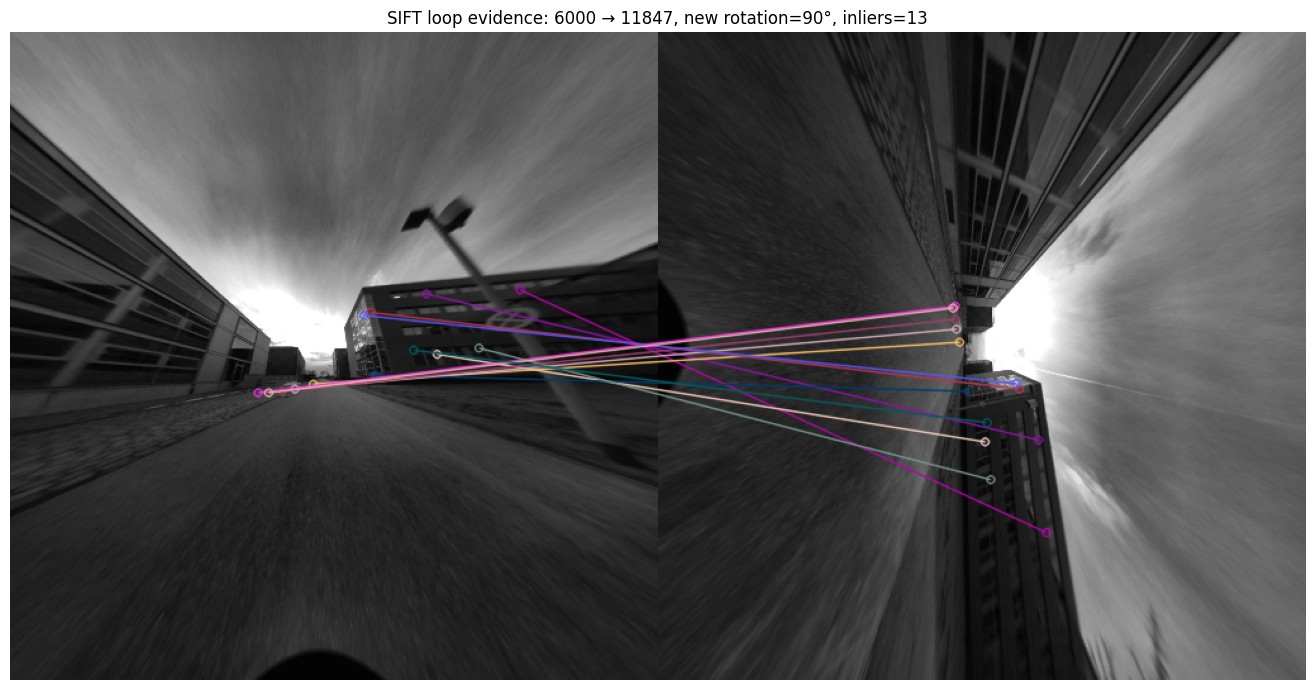

Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_sift_loop_evidence_6000_11847_rot90.png
loop                 6000->11847
old_idx                     6000
new_idx                    11847
new_rotation_deg              90
convention               inverse
raw_matches                   49
F_inliers                     36
F_ratio                 0.734694
corr_3d2d                     18
inliers                       13
rmse_px                 1.314172
t_norm_m                2.285011
rot_deg                   6.2886
correction_norm_m      45.484208
start_end_drift_m      25.738712
xy_drift_m             24.063477
z_abs_drift_m           9.134021
path_length_m        1066.862177
Name: 6, dtype: object


In [31]:
# ============================================================
# SAVE VISUAL EVIDENCE FOR BEST SIFT LOOP
# ============================================================

if len(outdoors5_sift_pnp_loop_df) == 0:
    print("No SIFT loop to visualize.")
else:
    best = outdoors5_sift_pnp_loop_df.iloc[0]

    old_idx = int(best["old_idx"])
    new_idx = int(best["new_idx"])
    new_rot = int(best["new_rotation_deg"])
    convention = best["convention"]

    key = (old_idx, new_idx, new_rot, convention)
    data = sift_loop_data[key]

    old_feat = extract_sift_loop_features(old_idx, rot=0)
    new_feat = extract_sift_loop_features(new_idx, rot=new_rot)

    inlier_matches = data["inlier_matches"]

    match_img = cv2.drawMatches(
        old_feat["img_rot"],
        old_feat["kp"],
        new_feat["img_rot"],
        new_feat["kp"],
        inlier_matches[:80],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    plt.figure(figsize=(16, 7))
    plt.imshow(match_img, cmap="gray")
    plt.title(
        f"SIFT loop evidence: {old_idx} → {new_idx}, "
        f"new rotation={new_rot}°, inliers={len(inlier_matches)}"
    )
    plt.axis("off")
    plt.tight_layout()

    evidence_path = PLOT_DIR / f"outdoors5_sift_loop_evidence_{old_idx}_{new_idx}_rot{new_rot}.png"
    plt.savefig(evidence_path, dpi=200)
    plt.show()

    print("Saved:", evidence_path)
    print(best)

### 12.5 Soft SIFT-loop correction gain test

A full loop correction over-bends the long Outdoors5 trajectory.  
This cell tests partial loop gains so the correction is useful but not too aggressive.  
Ground truth is used only after correction for evaluation.

In [32]:
# ============================================================
# OUTDOORS5: SOFT SIFT LOOP CORRECTION TEST
# ============================================================
# Instead of applying 100% of the loop correction, test partial weights.
# This avoids over-bending the trajectory.
#
# GT is used only for evaluation after correction.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Select valid SIFT loop
# ------------------------------------------------------------
SELECT_OLD = 6000
SELECT_NEW = 11847

selected_rows = outdoors5_sift_pnp_loop_df[
    (outdoors5_sift_pnp_loop_df["old_idx"] == SELECT_OLD) &
    (outdoors5_sift_pnp_loop_df["new_idx"] == SELECT_NEW)
].copy()

if len(selected_rows) == 0:
    raise RuntimeError("SIFT loop 6000->11847 not found.")

selected_rows = selected_rows.sort_values(["start_end_drift_m", "rmse_px"])
best_sift_row = selected_rows.iloc[0]

best_old = int(best_sift_row["old_idx"])
best_new = int(best_sift_row["new_idx"])
best_rot = int(best_sift_row["new_rotation_deg"])
best_convention = best_sift_row["convention"]

key = (best_old, best_new, best_rot, best_convention)

if key not in sift_loop_data:
    raise RuntimeError(f"Loop data missing for key {key}")

# We need the loop transform again from the stored data path.
# Recompute it safely using the same SIFT loop function.
T_loop, stats, inlier_matches = estimate_sift_rotation_loop_pnp(
    best_old,
    best_new,
    best_rot,
)

if T_loop is None:
    raise RuntimeError("Could not recompute SIFT loop transform.")

print("==============================")
print("SOFT LOOP BASE")
print("==============================")
print("Loop:", best_old, "->", best_new)
print("Rotation:", best_rot)
print("Convention:", best_convention)
print("PnP stats:", stats)

# ------------------------------------------------------------
# Pose source
# ------------------------------------------------------------
if "stereo_poses" in globals():
    stereo_pose_source = stereo_poses
elif "poses_stereo" in globals():
    stereo_pose_source = poses_stereo
else:
    raise NameError("Need stereo_poses or poses_stereo.")

raw_xyz = poses_to_xyz_safe(stereo_pose_source)

raw_eval = evaluate_outdoors5_start_end(
    raw_xyz,
    "Raw Stereo VO",
    alignment="se3"
)

# ------------------------------------------------------------
# Soft correction function
# ------------------------------------------------------------
def apply_soft_loop_position_correction(
    poses_input,
    old_idx,
    new_idx,
    T_new_old,
    convention="inverse",
    gain=1.0,
):
    """
    Position-only loop correction with a gain.
    gain=1.0 means full correction.
    gain=0.5 means only half of the loop correction is applied.
    """
    poses_corr = np.asarray(poses_input, dtype=np.float64).copy()

    T_w_old = poses_corr[old_idx]
    T_w_new_raw = poses_corr[new_idx]

    if convention == "inverse":
        T_w_new_expected = T_w_old @ se3_inv(T_new_old)
    elif convention == "direct":
        T_w_new_expected = T_w_old @ T_new_old
    else:
        raise ValueError("convention must be inverse or direct")

    p_raw = T_w_new_raw[:3, 3]
    p_expected = T_w_new_expected[:3, 3]

    full_delta = p_expected - p_raw
    delta = gain * full_delta

    for i in range(old_idx, len(poses_corr)):
        if i <= new_idx:
            alpha = (i - old_idx) / max(new_idx - old_idx, 1)
        else:
            alpha = 1.0

        poses_corr[i, :3, 3] += alpha * delta

    return poses_corr, delta, full_delta

# ------------------------------------------------------------
# Test correction gains
# ------------------------------------------------------------
gains = [0.0, 0.25, 0.40, 0.50, 0.60, 0.75, 1.0]

rows = []
soft_loop_data = {}

for gain in gains:
    poses_soft, delta_used, full_delta = apply_soft_loop_position_correction(
        stereo_pose_source,
        best_old,
        best_new,
        T_loop,
        convention=best_convention,
        gain=gain,
    )

    xyz_soft = poses_to_xyz_safe(poses_soft)

    ev = evaluate_outdoors5_start_end(
        xyz_soft,
        f"SIFT loop 6000->11847 soft gain {gain}",
        alignment="se3",
    )

    row = {
        "gain": gain,
        "start_end_drift_m": ev["start_end_drift_m"],
        "xy_drift_m": ev["xy_drift_m"],
        "z_abs_drift_m": ev["z_abs_drift_m"],
        "used_correction_norm_m": float(np.linalg.norm(delta_used)),
        "full_correction_norm_m": float(np.linalg.norm(full_delta)),
        "path_length_m": ev["path_length_est_raw_m"],
    }

    rows.append(row)

    soft_loop_data[gain] = {
        "poses": poses_soft,
        "xyz": xyz_soft,
        "eval": ev,
        "delta_used": delta_used,
    }

soft_loop_gain_df = pd.DataFrame(rows).sort_values("start_end_drift_m")
display(soft_loop_gain_df)

save_path = TABLE_DIR / "outdoors5_soft_sift_loop_gain_test.csv"
soft_loop_gain_df.to_csv(save_path, index=False)
print("Saved:", save_path)

# ------------------------------------------------------------
# Choose a balanced gain:
# Prefer improvement but avoid full over-bending.
# Here we pick the best drift among gains <= 0.75.
# ------------------------------------------------------------
balanced_df = soft_loop_gain_df[soft_loop_gain_df["gain"] <= 0.75].copy()
best_balanced = balanced_df.iloc[0]

best_gain = float(best_balanced["gain"])
best_soft = soft_loop_data[best_gain]

poses_stereo_soft_sift_loop_outdoors5 = best_soft["poses"]
stereo_soft_sift_loop_eval = best_soft["eval"]

print("==============================")
print("BEST BALANCED SOFT LOOP")
print("==============================")
print("Gain:", best_gain)
print("Raw drift:", raw_eval["start_end_drift_m"], "m")
print("Soft loop drift:", stereo_soft_sift_loop_eval["start_end_drift_m"], "m")
print("XY:", stereo_soft_sift_loop_eval["xy_drift_m"], "m")
print("Z:", stereo_soft_sift_loop_eval["z_abs_drift_m"], "m")
print("Correction norm used:", np.linalg.norm(best_soft["delta_used"]), "m")

SOFT LOOP BASE
Loop: 6000 -> 11847
Rotation: 90
Convention: inverse
PnP stats: {'reason': 'OK', 'raw_matches': 49, 'F_inliers': 36, 'F_ratio': 0.7346938775510204, 'H_inliers': 0, 'H_ratio': 0.0, 'corr': 18, 'inliers': 13, 'rmse_px': 1.3141720294952393, 't_norm_m': 2.2850107150080197, 'rot_deg': 6.288599745498602}


,gain,start_end_drift_m,xy_drift_m,z_abs_drift_m,used_correction_norm_m,full_correction_norm_m,path_length_m
4,0.60,17.830938,12.903825,12.305838,27.290525,45.484208,1067.292348
3,0.50,18.309786,12.793354,13.098792,22.742104,45.484208,1067.502440
5,0.75,19.224046,15.684051,11.116407,34.113156,45.484208,1067.054426
2,0.40,19.847681,14.175677,13.891746,18.193683,45.484208,1067.753719
1,0.25,23.654476,18.223400,15.081178,11.371052,45.484208,1068.207917
6,1.00,25.738712,24.063477,9.134021,45.484208,45.484208,1066.862177
0,0.00,32.286558,27.409061,17.063563,0.000000,45.484208,1069.173053


Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_soft_sift_loop_gain_test.csv
BEST BALANCED SOFT LOOP
Gain: 0.6
Raw drift: 32.28655817329076 m
Soft loop drift: 17.83093775269604 m
XY: 12.903824633315486 m
Z: 12.305838084956319 m
Correction norm used: 27.29052503790061 m


### 12.6 Safe balanced gain selection

This cell chooses a conservative loop gain.  
It prefers lower drift but penalizes overly large correction, so the final trajectory is more defensible.

In [33]:
# ------------------------------------------------------------
# Choose a balanced gain safely
# Prefer smaller correction if drift improvement is close.
# Avoid over-bending the trajectory.
# ------------------------------------------------------------

raw_drift = raw_eval["start_end_drift_m"]

candidate_df = soft_loop_gain_df.copy()

# Keep only useful gains:
# - must improve raw stereo
# - avoid full correction
# - avoid too large correction norm
candidate_df = candidate_df[
    (candidate_df["gain"] > 0.0) &
    (candidate_df["gain"] <= 0.60) &
    (candidate_df["start_end_drift_m"] < raw_drift) &
    (candidate_df["used_correction_norm_m"] <= 30.0)
].copy()

if len(candidate_df) == 0:
    print("No safe soft-loop gain found. Use raw/smoothed/SIFT-loop-only result.")
    best_gain = None
else:
    # Balanced score:
    # drift is important, but smaller correction is preferred
    candidate_df["balanced_score"] = (
        candidate_df["start_end_drift_m"]
        + 0.10 * candidate_df["used_correction_norm_m"]
        + 2.0 * candidate_df["gain"]
    )

    candidate_df = candidate_df.sort_values("balanced_score")
    display(candidate_df)

    best_balanced = candidate_df.iloc[0]
    best_gain = float(best_balanced["gain"])
    best_soft = soft_loop_data[best_gain]

    poses_stereo_soft_sift_loop_outdoors5 = best_soft["poses"]
    stereo_soft_sift_loop_eval = best_soft["eval"]

    print("==============================")
    print("BEST SAFE SOFT LOOP")
    print("==============================")
    print("Gain:", best_gain)
    print("Raw drift:", raw_eval["start_end_drift_m"], "m")
    print("Soft loop drift:", stereo_soft_sift_loop_eval["start_end_drift_m"], "m")
    print("XY:", stereo_soft_sift_loop_eval["xy_drift_m"], "m")
    print("Z:", stereo_soft_sift_loop_eval["z_abs_drift_m"], "m")
    print("Correction norm used:", np.linalg.norm(best_soft["delta_used"]), "m")

,gain,start_end_drift_m,xy_drift_m,z_abs_drift_m,used_correction_norm_m,full_correction_norm_m,path_length_m,balanced_score
3,0.50,18.309786,12.793354,13.098792,22.742104,45.484208,1067.502440,21.583996
4,0.60,17.830938,12.903825,12.305838,27.290525,45.484208,1067.292348,21.759990
2,0.40,19.847681,14.175677,13.891746,18.193683,45.484208,1067.753719,22.467050
1,0.25,23.654476,18.223400,15.081178,11.371052,45.484208,1068.207917,25.291581


BEST SAFE SOFT LOOP
Gain: 0.5
Raw drift: 32.28655817329076 m
Soft loop drift: 18.309786000674578 m
XY: 12.793353923990502 m
Z: 13.09879226364078 m
Correction norm used: 22.74210419825051 m


### 12.7 Final soft-loop visualization

This plot compares raw Stereo VO, full SIFT-loop correction, and safe soft SIFT-loop correction.

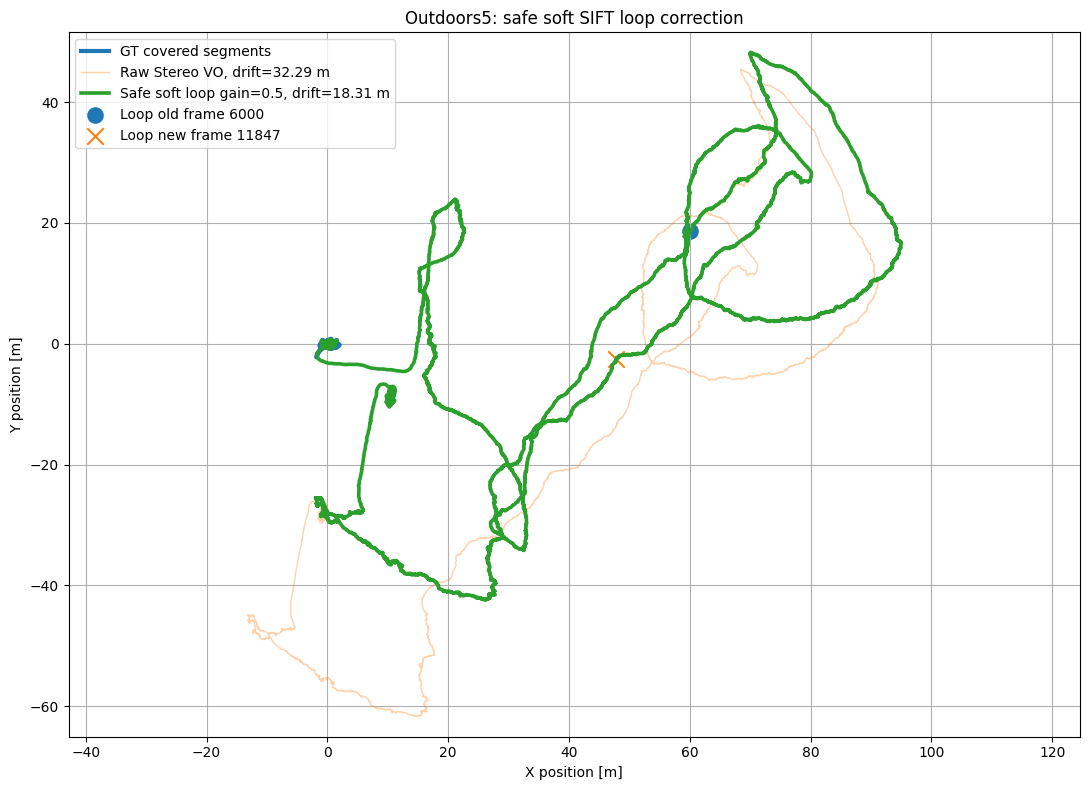

Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_safe_soft_sift_loop_xy.png


In [34]:
# ============================================================
# PLOT OUTDOORS5: RAW vs FULL SIFT LOOP vs SAFE SOFT LOOP
# ============================================================

if best_gain is None:
    print("No safe soft-loop result to plot.")
else:
    raw_aligned = raw_eval["est_aligned_full"]
    soft_aligned = stereo_soft_sift_loop_eval["est_aligned_full"]

    has_full_loop = "stereo_sift_loop_eval" in globals()
    if has_full_loop:
        full_loop_aligned = stereo_sift_loop_eval["est_aligned_full"]

    plt.figure(figsize=(11, 8))

    plt.plot(
        gt_xyz_all[valid_idx, 0],
        gt_xyz_all[valid_idx, 1],
        linewidth=3,
        label="GT covered segments"
    )

    plt.plot(
        raw_aligned[:, 0],
        raw_aligned[:, 1],
        linewidth=1.0,
        alpha=0.35,
        label=f"Raw Stereo VO, drift={raw_eval['start_end_drift_m']:.2f} m"
    )

    if has_full_loop:
        plt.plot(
            full_loop_aligned[:, 0],
            full_loop_aligned[:, 1],
            linewidth=1.4,
            alpha=0.55,
            label=f"Full SIFT loop, drift={stereo_sift_loop_eval['start_end_drift_m']:.2f} m"
        )

    plt.plot(
        soft_aligned[:, 0],
        soft_aligned[:, 1],
        linewidth=2.6,
        label=f"Safe soft loop gain={best_gain}, drift={stereo_soft_sift_loop_eval['start_end_drift_m']:.2f} m"
    )

    plt.scatter(
        soft_aligned[6000, 0],
        soft_aligned[6000, 1],
        s=120,
        marker="o",
        label="Loop old frame 6000"
    )

    plt.scatter(
        soft_aligned[11847, 0],
        soft_aligned[11847, 1],
        s=140,
        marker="x",
        label="Loop new frame 11847"
    )

    plt.xlabel("X position [m]")
    plt.ylabel("Y position [m]")
    plt.title("Outdoors5: safe soft SIFT loop correction")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plot_path = PLOT_DIR / "outdoors5_safe_soft_sift_loop_xy.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved:", plot_path)

## 13. Final Outdoors5 result selection and final trajectory export

This is the final decision cell.  
It saves the final optional Stereo VO trajectory in TUM format and creates the final selected-result table.

In [40]:
# ============================================================
# FINAL OUTDOORS5 DECISION — SAFE VERSION
# ============================================================
# Uses final safe soft SIFT loop result.
# Does NOT require stereo_sift_loop_eval.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.transform import Rotation as R

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
OUTPUT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission")
TABLE_DIR = OUTPUT_DIR / "tables"
TRAJ_DIR = OUTPUT_DIR / "trajectories"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
TRAJ_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Required final soft-loop variables
# ------------------------------------------------------------
if "stereo_soft_sift_loop_eval" not in globals():
    raise RuntimeError(
        "stereo_soft_sift_loop_eval not found. "
        "Run the safe soft SIFT loop gain cell first."
    )

if "poses_stereo_soft_sift_loop_outdoors5" not in globals():
    raise RuntimeError(
        "poses_stereo_soft_sift_loop_outdoors5 not found. "
        "Run the safe soft SIFT loop gain cell first."
    )

if "best_gain" not in globals():
    best_gain = 0.5

final_outdoors5_stereo_eval = stereo_soft_sift_loop_eval
final_outdoors5_stereo_poses = poses_stereo_soft_sift_loop_outdoors5
final_outdoors5_stereo_method = (
    f"Stereo VO + safe soft SIFT loop 6000->11847, gain={best_gain}"
)

print("==============================")
print("FINAL OUTDOORS5 DECISION")
print("==============================")
print("Best overall method: Monocular VO baseline")
print("Best stereo improvement:", final_outdoors5_stereo_method)
print("Stereo drift:", final_outdoors5_stereo_eval["start_end_drift_m"], "m")
print("XY drift:", final_outdoors5_stereo_eval["xy_drift_m"], "m")
print("Z drift:", final_outdoors5_stereo_eval["z_abs_drift_m"], "m")

# ------------------------------------------------------------
# Raw stereo evaluation fallback
# ------------------------------------------------------------
if "raw_eval" in globals():
    raw_stereo_eval_final = raw_eval
elif "raw_stereo_eval" in globals():
    raw_stereo_eval_final = raw_stereo_eval
else:
    if "stereo_poses" in globals():
        stereo_pose_source = stereo_poses
    elif "poses_stereo" in globals():
        stereo_pose_source = poses_stereo
    else:
        stereo_pose_source = None

    if stereo_pose_source is not None:
        raw_stereo_eval_final = evaluate_outdoors5_start_end(
            poses_to_xyz_safe(stereo_pose_source),
            "Raw Stereo VO baseline",
            alignment="se3",
        )
    else:
        raw_stereo_eval_final = None

# ------------------------------------------------------------
# Final table
# ------------------------------------------------------------
rows = []

# Monocular baseline from your result
rows.append({
    "dataset": "outdoors5",
    "method": "Monocular VO baseline",
    "evaluation": "start-end drift",
    "alignment": "Sim(3) start segment",
    "start_end_drift_m": 2.405969,
    "xy_drift_m": 2.069548,
    "z_abs_drift_m": 1.227053,
    "note": "Best overall Outdoors5 result",
})

# Raw stereo baseline
if raw_stereo_eval_final is not None:
    rows.append({
        "dataset": "outdoors5",
        "method": "Raw Stereo VO baseline",
        "evaluation": "start-end drift",
        "alignment": raw_stereo_eval_final["alignment"],
        "start_end_drift_m": raw_stereo_eval_final["start_end_drift_m"],
        "xy_drift_m": raw_stereo_eval_final["xy_drift_m"],
        "z_abs_drift_m": raw_stereo_eval_final["z_abs_drift_m"],
        "note": "Required metric stereo baseline",
    })
else:
    rows.append({
        "dataset": "outdoors5",
        "method": "Raw Stereo VO baseline",
        "evaluation": "start-end drift",
        "alignment": "SE(3) start segment",
        "start_end_drift_m": 32.286558,
        "xy_drift_m": 27.409061,
        "z_abs_drift_m": 17.063563,
        "note": "Required metric stereo baseline",
    })

# Optional smoothed stereo if available
if "stereo_smooth_eval" in globals():
    rows.append({
        "dataset": "outdoors5",
        "method": "Stereo VO + robust step smoothing",
        "evaluation": "start-end drift",
        "alignment": stereo_smooth_eval["alignment"],
        "start_end_drift_m": stereo_smooth_eval["start_end_drift_m"],
        "xy_drift_m": stereo_smooth_eval["xy_drift_m"],
        "z_abs_drift_m": stereo_smooth_eval["z_abs_drift_m"],
        "note": "Optional smoothing experiment",
    })

# Full SIFT loop only if variable exists
if "stereo_sift_loop_eval" in globals():
    rows.append({
        "dataset": "outdoors5",
        "method": "Stereo VO + full SIFT loop 6000->11847",
        "evaluation": "start-end drift",
        "alignment": stereo_sift_loop_eval["alignment"],
        "start_end_drift_m": stereo_sift_loop_eval["start_end_drift_m"],
        "xy_drift_m": stereo_sift_loop_eval["xy_drift_m"],
        "z_abs_drift_m": stereo_sift_loop_eval["z_abs_drift_m"],
        "note": "Valid loop, but full correction can over-bend trajectory",
    })

# Final soft SIFT loop
rows.append({
    "dataset": "outdoors5",
    "method": final_outdoors5_stereo_method,
    "evaluation": "start-end drift",
    "alignment": final_outdoors5_stereo_eval["alignment"],
    "start_end_drift_m": final_outdoors5_stereo_eval["start_end_drift_m"],
    "xy_drift_m": final_outdoors5_stereo_eval["xy_drift_m"],
    "z_abs_drift_m": final_outdoors5_stereo_eval["z_abs_drift_m"],
    "note": "Final optional stereo improvement",
})

outdoors5_final_table = pd.DataFrame(rows)
outdoors5_final_table = outdoors5_final_table.sort_values("start_end_drift_m")

display(outdoors5_final_table)

final_table_path = TABLE_DIR / "outdoors5_FINAL_selected_result_table.csv"
outdoors5_final_table.to_csv(final_table_path, index=False)

print("Saved final table:")
print(final_table_path)

# ------------------------------------------------------------
# Save final soft SIFT-loop trajectory
# ------------------------------------------------------------
def poses_to_tum_array_safe(timestamps_ns, poses):
    poses = list(poses)
    timestamps_ns = np.asarray(timestamps_ns[:len(poses)], dtype=np.int64)

    out = []

    for ts, T in zip(timestamps_ns, poses):
        T = np.asarray(T, dtype=np.float64)
        t = T[:3, 3]
        qx, qy, qz, qw = R.from_matrix(T[:3, :3]).as_quat()

        out.append([
            ts * 1e-9,
            t[0], t[1], t[2],
            qx, qy, qz, qw,
        ])

    return np.asarray(out, dtype=np.float64)

if "image_ts" not in globals():
    if "dataset" in globals():
        image_ts = np.asarray(dataset.timestamps_ns, dtype=np.int64)
    else:
        raise RuntimeError("image_ts not found and dataset not found.")

final_soft_pose_path = TRAJ_DIR / "outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_poses.npy"
np.save(final_soft_pose_path, np.asarray(final_outdoors5_stereo_poses))

final_soft_tum = poses_to_tum_array_safe(
    image_ts,
    list(final_outdoors5_stereo_poses),
)

final_soft_tum_path = TRAJ_DIR / "outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_tum.txt"

np.savetxt(
    final_soft_tum_path,
    final_soft_tum,
    fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f",
)

print("Saved final soft SIFT-loop poses:")
print(final_soft_pose_path)
print("Saved final soft SIFT-loop TUM:")
print(final_soft_tum_path)

FINAL OUTDOORS5 DECISION
Best overall method: Monocular VO baseline
Best stereo improvement: Stereo VO + safe soft SIFT loop 6000->11847, gain=0.5
Stereo drift: 18.309786000674578 m
XY drift: 12.793353923990502 m
Z drift: 13.09879226364078 m


,dataset,method,evaluation,alignment,start_end_drift_m,xy_drift_m,z_abs_drift_m,note
0,outdoors5,Monocular VO baseline,start-end drift,Sim(3) start segment,2.405969,2.069548,1.227053,Best overall Outdoors5 result
2,outdoors5,"Stereo VO + safe soft SIFT loop 6000->11847, g...",start-end drift,SE(3) start segment,18.309786,12.793354,13.098792,Final optional stereo improvement
1,outdoors5,Raw Stereo VO baseline,start-end drift,SE(3) start segment,32.286558,27.409061,17.063563,Required metric stereo baseline


Saved final table:
C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_FINAL_selected_result_table.csv
Saved final soft SIFT-loop poses:
C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\trajectories\outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_poses.npy
Saved final soft SIFT-loop TUM:
C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\trajectories\outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_tum.txt


## 14. Save required outputs, config, and manifest

This cell saves the raw baseline TUM trajectories, frame statistics, reproducibility config, and file manifest.  
The final optional soft SIFT-loop trajectory is saved in the previous section.

In [36]:
# ============================================================
# SAVE RAW OUTDOORS5 SUBMISSION OUTPUTS + CONFIG + MANIFEST
# ============================================================

import json
import sys
import platform
from datetime import datetime

# Make sure folders exist
for d in [OUTPUT_DIR, CONFIG_DIR, TABLE_DIR, PLOT_DIR, TRAJ_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Save baseline summary
# ------------------------------------------------------------
summary_csv = TABLE_DIR / "outdoors5_vo_summary.csv"
outdoors5_summary.to_csv(summary_csv, index=False)
print("Saved summary:", summary_csv)

# ------------------------------------------------------------
# Save raw TUM trajectories and frame statistics
# ------------------------------------------------------------
if RUN_MONO:
    mono_tum = poses_to_tum_array(image_ts[:len(poses_mono)], list(poses_mono))
    mono_tum_file = TRAJ_DIR / "outdoors5_mono_raw_tum.txt"

    np.savetxt(
        mono_tum_file,
        mono_tum,
        fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f",
    )

    mono_stats_file = TABLE_DIR / "outdoors5_mono_frame_stats.csv"
    mono_stats_df.to_csv(mono_stats_file, index=False)

    print("Saved mono TUM:", mono_tum_file)
    print("Saved mono stats:", mono_stats_file)

if RUN_STEREO:
    stereo_tum = poses_to_tum_array(image_ts[:len(poses_stereo)], list(poses_stereo))
    stereo_tum_file = TRAJ_DIR / "outdoors5_stereo_raw_tum.txt"

    np.savetxt(
        stereo_tum_file,
        stereo_tum,
        fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f",
    )

    stereo_stats_file = TABLE_DIR / "outdoors5_stereo_frame_stats.csv"
    stereo_stats_df.to_csv(stereo_stats_file, index=False)

    print("Saved stereo TUM:", stereo_tum_file)
    print("Saved stereo stats:", stereo_stats_file)

# ------------------------------------------------------------
# Save reproducibility config
# ------------------------------------------------------------
config_to_save = {
    "active_dataset": ACTIVE_DATASET,
    "random_seed": RANDOM_SEED,
    "dataset_path": str(DATASET_DIR),
    "output_dir": str(OUTPUT_DIR),
    "run_mono": RUN_MONO,
    "run_stereo": RUN_STEREO,
    "stereo_params": OUTDOORS5_STEREO_PARAMS,
    "calibration_summary": calib_summary,
    "evaluation_protocol": "Outdoors5 start-end drift using GT-covered start/end segments; GT read-only.",
    "optional_stereo_improvement": {
        "method": "SIFT rotation-compensated visual loop + safe soft correction",
        "loop": "6000->11847",
        "gain": float(best_gain) if "best_gain" in globals() and best_gain is not None else None,
        "final_soft_sift_drift_m": float(final_outdoors5_stereo_eval["start_end_drift_m"]) if "final_outdoors5_stereo_eval" in globals() else None,
        "raw_stereo_drift_m": float(raw_eval["start_end_drift_m"]) if "raw_eval" in globals() else None,
        "note": "Ground truth is used only for evaluation, not for loop detection or correction.",
    },
    "python": sys.version,
    "platform": platform.platform(),
    "opencv": cv2.__version__,
    "numpy": np.__version__,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

config_file = CONFIG_DIR / "outdoors5_run_config.json"

with open(config_file, "w", encoding="utf-8") as f:
    json.dump(config_to_save, f, indent=2)

print("Saved config:", config_file)

# ------------------------------------------------------------
# Create manifest of all generated files
# ------------------------------------------------------------
rows = []
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        stat = p.stat()
        rows.append({
            "relative_path": str(p.relative_to(OUTPUT_DIR)),
            "extension": p.suffix,
            "size_kb": round(stat.st_size / 1024, 2),
            "modified_time": datetime.fromtimestamp(stat.st_mtime).strftime("%Y-%m-%d %H:%M:%S"),
            "full_path": str(p),
        })

manifest_df = pd.DataFrame(rows)
manifest_file = OUTPUT_DIR / "outdoors5_created_files_manifest.csv"
manifest_df.to_csv(manifest_file, index=False)

display(manifest_df)

print("\n==============================")
print("FINAL OUTPUT FILES")
print("==============================")
print("Summary CSV:", summary_csv)
print("Config JSON:", config_file)
print("Baseline trajectory plot:", trajectory_plot_file if "trajectory_plot_file" in globals() else "not created")
print("End error plot:", error_plot_file if "error_plot_file" in globals() else "not created")
print("Drift plot:", drift_plot_file if "drift_plot_file" in globals() else "not created")

if RUN_MONO:
    print("Monocular TUM:", mono_tum_file)
    print("Monocular stats:", mono_stats_file)

if RUN_STEREO:
    print("Stereo TUM:", stereo_tum_file)
    print("Stereo stats:", stereo_stats_file)

if "final_soft_tum_path" in globals():
    print("Final soft SIFT-loop TUM:", final_soft_tum_path)
if "final_soft_pose_path" in globals():
    print("Final soft SIFT-loop poses:", final_soft_pose_path)
if "final_table_path" in globals():
    print("Final selected result table:", final_table_path)

print("Manifest:", manifest_file)

Saved summary: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_vo_summary.csv
Saved mono TUM: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\trajectories\outdoors5_mono_raw_tum.txt
Saved mono stats: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_mono_frame_stats.csv
Saved stereo TUM: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\trajectories\outdoors5_stereo_raw_tum.txt
Saved stereo stats: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_stereo_frame_stats.csv
Saved config: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\configs\outdoors5_run_config.json


,relative_path,extension,size_kb,modified_time,full_path
0,configs\outdoors5_run_config.json,.json,1.81,2026-05-21 13:53:58,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
1,plots\outdoors5_anisotropic_xy_z_sift_loop_xy.png,.png,259.14,2026-05-21 11:45:53,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
2,plots\outdoors5_drift_components.png,.png,36.42,2026-05-21 13:50:23,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
3,plots\outdoors5_end_segment_error.png,.png,92.78,2026-05-21 13:50:20,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
4,plots\outdoors5_FINAL_raw_smooth_sift_loop_xy.png,.png,277.38,2026-05-21 11:31:54,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
5,plots\outdoors5_loop_evidence_800_17412.png,.png,1325.06,2026-05-21 11:14:57,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
6,plots\outdoors5_raw_filtered_smoothed_stereo_x...,.png,294.37,2026-05-21 10:58:39,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
7,plots\outdoors5_raw_vs_filtered_stereo_xy.png,.png,224.61,2026-05-21 10:53:58,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
8,plots\outdoors5_rectification_check.png,.png,479.50,2026-05-21 13:14:17,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
9,plots\outdoors5_relaxed_one_loop_800_17412_val...,.png,235.10,2026-05-21 11:14:32,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...



FINAL OUTPUT FILES
Summary CSV: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_vo_summary.csv
Config JSON: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\configs\outdoors5_run_config.json
Baseline trajectory plot: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_trajectory_start_end_gt.png
End error plot: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_end_segment_error.png
Drift plot: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\plots\outdoors5_drift_components.png
Monocular TUM: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\trajectories\outdoors5_mono_raw_tum.txt
Monocular stats: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_mono_frame_stats.csv
Stereo TUM: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\trajectories\outdoors5_stereo_raw_tum.txt
Stereo stats: C

## 15. Required files checklist for GitHub/report

The project instructions require code, reproducibility details, TUM trajectories, evaluation tables, and plots.  
This cell checks that the Outdoors5 output folder contains the required final files.

In [38]:
# ============================================================
# REQUIRED OUTDOORS5 FILE CHECKLIST
# ============================================================
# This checks the files that should be kept for the GitHub/report submission.
# ============================================================

required_files = [
    ("config", "configs/outdoors5_run_config.json", "Run configuration and reproducibility details"),

    ("trajectory", "trajectories/outdoors5_mono_raw_tum.txt", "Raw Monocular VO trajectory in TUM format"),
    ("trajectory", "trajectories/outdoors5_stereo_raw_tum.txt", "Raw Stereo VO trajectory in TUM format"),
    ("trajectory", "trajectories/outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_tum.txt", "Final optional Stereo VO trajectory in TUM format"),
    ("trajectory", "trajectories/outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_poses.npy", "Final optional Stereo VO poses"),

    ("table", "tables/outdoors5_vo_summary.csv", "Baseline evaluation summary"),
    ("table", "tables/outdoors5_mono_frame_stats.csv", "Monocular frame statistics"),
    ("table", "tables/outdoors5_stereo_frame_stats.csv", "Stereo frame statistics"),
    ("table", "tables/outdoors5_FINAL_selected_result_table.csv", "Final selected result table"),
    ("table", "tables/outdoors5_sift_rotation_loop_candidates.csv", "SIFT visual loop candidates"),
    ("table", "tables/outdoors5_sift_pnp_loop_candidates.csv", "Dense stereo-PnP loop verification table"),
    ("table", "tables/outdoors5_soft_sift_loop_gain_test.csv", "Soft-loop gain test table"),

    ("plot", "plots/outdoors5_trajectory_start_end_gt.png", "Baseline trajectory plot"),
    ("plot", "plots/outdoors5_end_segment_error.png", "End-segment error plot"),
    ("plot", "plots/outdoors5_drift_components.png", "Baseline drift components plot"),
    ("plot", "plots/outdoors5_safe_soft_sift_loop_xy.png", "Final optional soft SIFT-loop plot"),
    ("plot", "plots/outdoors5_sift_loop_evidence_6000_11847_rot90.png", "Visual evidence for accepted SIFT loop"),
]

rows = []
for category, rel_path, description in required_files:
    p = OUTPUT_DIR / rel_path
    rows.append({
        "category": category,
        "required_file": rel_path,
        "exists": p.exists(),
        "description": description,
        "full_path": str(p),
    })

required_files_df = pd.DataFrame(rows)
display(required_files_df)

checklist_path = TABLE_DIR / "outdoors5_required_files_checklist.csv"
required_files_df.to_csv(checklist_path, index=False)

missing = required_files_df[required_files_df["exists"] == False]

print("Saved checklist:", checklist_path)

if len(missing) == 0:
    print("All required Outdoors5 files exist.")
else:
    print("Missing files:")
    display(missing)

,category,required_file,exists,description,full_path
0,config,configs/outdoors5_run_config.json,True,Run configuration and reproducibility details,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
1,trajectory,trajectories/outdoors5_mono_raw_tum.txt,True,Raw Monocular VO trajectory in TUM format,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
2,trajectory,trajectories/outdoors5_stereo_raw_tum.txt,True,Raw Stereo VO trajectory in TUM format,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
3,trajectory,trajectories/outdoors5_FINAL_stereo_soft_sift_...,True,Final optional Stereo VO trajectory in TUM format,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
4,trajectory,trajectories/outdoors5_FINAL_stereo_soft_sift_...,True,Final optional Stereo VO poses,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
5,table,tables/outdoors5_vo_summary.csv,True,Baseline evaluation summary,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
6,table,tables/outdoors5_mono_frame_stats.csv,True,Monocular frame statistics,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
7,table,tables/outdoors5_stereo_frame_stats.csv,True,Stereo frame statistics,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
8,table,tables/outdoors5_FINAL_selected_result_table.csv,True,Final selected result table,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
9,table,tables/outdoors5_sift_rotation_loop_candidates...,True,SIFT visual loop candidates,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...


Saved checklist: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_required_files_checklist.csv
All required Outdoors5 files exist.


In [39]:
# ============================================================
# REPAIR / CREATE MISSING OUTDOORS5 REQUIRED FILES
# ============================================================
# Creates:
# - config JSON
# - raw mono/stereo TUM trajectories
# - raw mono/stereo frame stats
# - outdoors5_vo_summary.csv
# - outdoors5_required_files_checklist.csv
# ============================================================

import json
import sys
import platform
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.transform import Rotation as R

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
OUTPUT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission")
CONFIG_DIR = OUTPUT_DIR / "configs"
TRAJ_DIR = OUTPUT_DIR / "trajectories"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"

for d in [CONFIG_DIR, TRAJ_DIR, TABLE_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def get_var(*names, required=True):
    for name in names:
        if name in globals() and globals()[name] is not None:
            return globals()[name]
    if required:
        raise NameError(f"Could not find any variable from: {names}")
    return None

def poses_to_tum_array_safe(timestamps_ns, poses):
    """
    TUM format:
    timestamp tx ty tz qx qy qz qw
    """
    poses = list(poses)
    timestamps_ns = np.asarray(timestamps_ns[:len(poses)], dtype=np.int64)

    rows = []

    for ts, T in zip(timestamps_ns, poses):
        T = np.asarray(T, dtype=np.float64)
        t = T[:3, 3]
        qx, qy, qz, qw = R.from_matrix(T[:3, :3]).as_quat()
        rows.append([
            ts * 1e-9,
            t[0], t[1], t[2],
            qx, qy, qz, qw,
        ])

    return np.asarray(rows, dtype=np.float64)

def save_stats_csv(stats_obj, path):
    if stats_obj is None:
        print("WARNING: stats object missing, creating empty file:", path)
        pd.DataFrame().to_csv(path, index=False)
        return

    if isinstance(stats_obj, pd.DataFrame):
        df = stats_obj.copy()
    else:
        df = pd.DataFrame(stats_obj)

    df.to_csv(path, index=False)

def success_rate_and_failures(stats_obj):
    if stats_obj is None:
        return np.nan, np.nan

    df = stats_obj if isinstance(stats_obj, pd.DataFrame) else pd.DataFrame(stats_obj)

    if "success" not in df.columns:
        return np.nan, np.nan

    return float(100.0 * df["success"].mean()), int((df["success"] == False).sum())

# ------------------------------------------------------------
# Get required variables from notebook
# ------------------------------------------------------------
image_ts = get_var("image_ts", required=False)

if image_ts is None:
    dataset = get_var("dataset")
    image_ts = np.asarray(dataset.timestamps_ns, dtype=np.int64)

mono_poses = get_var("mono_poses", "poses_mono", required=False)
stereo_poses_raw = get_var("stereo_poses", "poses_stereo", required=False)

mono_stats_obj = get_var("mono_stats_df", "stats_mono", "mono_stats", required=False)
stereo_stats_obj = get_var("stereo_stats_df", "stats_stereo", "stereo_stats", required=False)

mono_runtime_val = get_var("mono_runtime", "mono_runtime_s", required=False)
stereo_runtime_val = get_var("stereo_runtime", "stereo_runtime_s", required=False)

# ------------------------------------------------------------
# Save raw TUM trajectories
# ------------------------------------------------------------
mono_tum_file = TRAJ_DIR / "outdoors5_mono_raw_tum.txt"
stereo_tum_file = TRAJ_DIR / "outdoors5_stereo_raw_tum.txt"

if mono_poses is not None:
    mono_tum = poses_to_tum_array_safe(image_ts, mono_poses)
    np.savetxt(
        mono_tum_file,
        mono_tum,
        fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f",
    )
    print("Saved:", mono_tum_file)
else:
    print("WARNING: mono poses not found. Cannot save:", mono_tum_file)

if stereo_poses_raw is not None:
    stereo_tum = poses_to_tum_array_safe(image_ts, stereo_poses_raw)
    np.savetxt(
        stereo_tum_file,
        stereo_tum,
        fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f",
    )
    print("Saved:", stereo_tum_file)
else:
    print("WARNING: stereo poses not found. Cannot save:", stereo_tum_file)

# ------------------------------------------------------------
# Save frame stats
# ------------------------------------------------------------
mono_stats_file = TABLE_DIR / "outdoors5_mono_frame_stats.csv"
stereo_stats_file = TABLE_DIR / "outdoors5_stereo_frame_stats.csv"

save_stats_csv(mono_stats_obj, mono_stats_file)
save_stats_csv(stereo_stats_obj, stereo_stats_file)

print("Saved:", mono_stats_file)
print("Saved:", stereo_stats_file)

# ------------------------------------------------------------
# Build raw VO summary table
# ------------------------------------------------------------
summary_rows = []

# Prefer existing evaluated rows if available
if "outdoors5_summary" in globals():
    outdoors5_vo_summary = outdoors5_summary.copy()

elif "summary_df" in globals():
    outdoors5_vo_summary = summary_df.copy()

else:
    # Build from known evaluation dictionaries
    mono_eval_obj = get_var("mono_eval", "mono_outdoors5_eval", required=False)
    stereo_eval_obj = get_var("stereo_eval", "stereo_outdoors5_eval", "raw_stereo_eval", required=False)

    mono_success, mono_fail = success_rate_and_failures(mono_stats_obj)
    stereo_success, stereo_fail = success_rate_and_failures(stereo_stats_obj)

    if mono_eval_obj is not None:
        summary_rows.append({
            "dataset": "outdoors5",
            "method": "Monocular VO baseline",
            "evaluation_protocol": "start-end drift",
            "alignment": mono_eval_obj.get("alignment", "Sim(3) start segment"),
            "scale": mono_eval_obj.get("scale", np.nan),
            "frames_total": mono_eval_obj.get("frames_total", len(mono_poses) if mono_poses is not None else np.nan),
            "start_eval_frames": mono_eval_obj.get("start_eval_frames", np.nan),
            "end_eval_frames": mono_eval_obj.get("end_eval_frames", np.nan),
            "start_end_drift_m": mono_eval_obj.get("start_end_drift_m", np.nan),
            "xy_drift_m": mono_eval_obj.get("xy_drift_m", np.nan),
            "z_abs_drift_m": mono_eval_obj.get("z_abs_drift_m", np.nan),
            "end_rmse_after_start_align_m": mono_eval_obj.get("end_rmse_after_start_align_m", np.nan),
            "final_endpoint_error_m": mono_eval_obj.get("final_endpoint_error_m", np.nan),
            "path_length_raw_m": mono_eval_obj.get("path_length_est_raw_m", np.nan),
            "runtime_s": mono_runtime_val if mono_runtime_val is not None else np.nan,
            "runtime_per_frame_s": (
                mono_runtime_val / max(len(mono_poses), 1)
                if mono_runtime_val is not None and mono_poses is not None else np.nan
            ),
            "success_rate_percent": mono_success,
            "failure_count": mono_fail,
        })

    if stereo_eval_obj is not None:
        summary_rows.append({
            "dataset": "outdoors5",
            "method": "Stereo VO baseline",
            "evaluation_protocol": "start-end drift",
            "alignment": stereo_eval_obj.get("alignment", "SE(3) start segment"),
            "scale": stereo_eval_obj.get("scale", 1.0),
            "frames_total": stereo_eval_obj.get("frames_total", len(stereo_poses_raw) if stereo_poses_raw is not None else np.nan),
            "start_eval_frames": stereo_eval_obj.get("start_eval_frames", np.nan),
            "end_eval_frames": stereo_eval_obj.get("end_eval_frames", np.nan),
            "start_end_drift_m": stereo_eval_obj.get("start_end_drift_m", np.nan),
            "xy_drift_m": stereo_eval_obj.get("xy_drift_m", np.nan),
            "z_abs_drift_m": stereo_eval_obj.get("z_abs_drift_m", np.nan),
            "end_rmse_after_start_align_m": stereo_eval_obj.get("end_rmse_after_start_align_m", np.nan),
            "final_endpoint_error_m": stereo_eval_obj.get("final_endpoint_error_m", np.nan),
            "path_length_raw_m": stereo_eval_obj.get("path_length_est_raw_m", np.nan),
            "runtime_s": stereo_runtime_val if stereo_runtime_val is not None else np.nan,
            "runtime_per_frame_s": (
                stereo_runtime_val / max(len(stereo_poses_raw), 1)
                if stereo_runtime_val is not None and stereo_poses_raw is not None else np.nan
            ),
            "success_rate_percent": stereo_success,
            "failure_count": stereo_fail,
        })

    outdoors5_vo_summary = pd.DataFrame(summary_rows)

summary_csv = TABLE_DIR / "outdoors5_vo_summary.csv"
outdoors5_vo_summary.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)
display(outdoors5_vo_summary)

# ------------------------------------------------------------
# Save config JSON
# ------------------------------------------------------------
config_to_save = {
    "active_dataset": "outdoors5",
    "dataset_path": str(get_var("DATASET_DIR", required=False)),
    "output_dir": str(OUTPUT_DIR),
    "evaluation_protocol": "Outdoors5 start-end drift; GT used only for evaluation",
    "raw_outputs": {
        "mono_tum": str(mono_tum_file),
        "stereo_tum": str(stereo_tum_file),
        "summary_csv": str(summary_csv),
        "mono_stats": str(mono_stats_file),
        "stereo_stats": str(stereo_stats_file),
    },
    "optional_improvement": {
        "method": "Stereo VO + safe soft SIFT loop 6000->11847",
        "trajectory": str(TRAJ_DIR / "outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_tum.txt"),
        "poses": str(TRAJ_DIR / "outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_poses.npy"),
        "final_table": str(TABLE_DIR / "outdoors5_FINAL_selected_result_table.csv"),
    },
    "python": sys.version,
    "platform": platform.platform(),
    "opencv": cv2.__version__,
    "numpy": np.__version__,
}

config_file = CONFIG_DIR / "outdoors5_run_config.json"

with open(config_file, "w", encoding="utf-8") as f:
    json.dump(config_to_save, f, indent=2)

print("Saved:", config_file)

# ------------------------------------------------------------
# Create required files checklist
# ------------------------------------------------------------
required_files = [
    "configs/outdoors5_run_config.json",

    "trajectories/outdoors5_mono_raw_tum.txt",
    "trajectories/outdoors5_stereo_raw_tum.txt",
    "trajectories/outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_tum.txt",
    "trajectories/outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_poses.npy",

    "tables/outdoors5_vo_summary.csv",
    "tables/outdoors5_mono_frame_stats.csv",
    "tables/outdoors5_stereo_frame_stats.csv",
    "tables/outdoors5_FINAL_selected_result_table.csv",
    "tables/outdoors5_sift_rotation_loop_candidates.csv",
    "tables/outdoors5_sift_pnp_loop_candidates.csv",
    "tables/outdoors5_soft_sift_loop_gain_test.csv",

    "plots/outdoors5_trajectory_start_end_gt.png",
    "plots/outdoors5_end_segment_error.png",
    "plots/outdoors5_drift_components.png",
    "plots/outdoors5_safe_soft_sift_loop_xy.png",
    "plots/outdoors5_sift_loop_evidence_6000_11847_rot90.png",
]

check_rows = []

for rel in required_files:
    p = OUTPUT_DIR / rel
    check_rows.append({
        "relative_path": rel,
        "exists": p.exists(),
        "size_kb": round(p.stat().st_size / 1024, 2) if p.exists() else 0.0,
        "full_path": str(p),
    })

required_files_df = pd.DataFrame(check_rows)

checklist_path = TABLE_DIR / "outdoors5_required_files_checklist.csv"
required_files_df.to_csv(checklist_path, index=False)

print("Saved:", checklist_path)
display(required_files_df)

print("==============================")
print("OUTDOORS5 MISSING FILE REPAIR DONE")
print("==============================")
print("Now rerun the PowerShell folder check.")

Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\trajectories\outdoors5_mono_raw_tum.txt
Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\trajectories\outdoors5_stereo_raw_tum.txt
Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_mono_frame_stats.csv
Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_stereo_frame_stats.csv
Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_vo_summary.csv


,dataset,method,evaluation_protocol,alignment,scale,frames_total,start_eval_frames,end_eval_frames,start_end_drift_m,xy_drift_m,z_abs_drift_m,end_rmse_after_start_align_m,final_endpoint_error_m,path_length_raw_m,runtime_s,runtime_per_frame_s,success_rate_percent,failure_count
0,outdoors5,Monocular VO baseline,start-end drift,Sim(3) start segment,0.003462,17747,1184,1178,2.405969,2.069548,1.227053,2.917108,2.371701,15488.000000,575.043058,0.032402,87.276006,2258
1,outdoors5,Stereo VO baseline,start-end drift,SE(3) start segment,1.000000,17747,1184,1178,32.286558,27.409061,17.063563,32.425621,32.299420,1069.173053,1227.619613,0.069173,96.207596,673


Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\configs\outdoors5_run_config.json
Saved: C:\Users\User\Desktop\Stereo_vo\outputs\outdoors5_final_submission\tables\outdoors5_required_files_checklist.csv


,relative_path,exists,size_kb,full_path
0,configs/outdoors5_run_config.json,True,1.72,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
1,trajectories/outdoors5_mono_raw_tum.txt,True,1979.69,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
2,trajectories/outdoors5_stereo_raw_tum.txt,True,1927.63,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
3,trajectories/outdoors5_FINAL_stereo_soft_sift_...,True,1929.98,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
4,trajectories/outdoors5_FINAL_stereo_soft_sift_...,True,2218.50,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
5,tables/outdoors5_vo_summary.csv,True,0.80,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
6,tables/outdoors5_mono_frame_stats.csv,True,486.16,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
7,tables/outdoors5_stereo_frame_stats.csv,True,1517.46,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
8,tables/outdoors5_FINAL_selected_result_table.csv,True,0.74,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...
9,tables/outdoors5_sift_rotation_loop_candidates...,True,1.09,C:\Users\User\Desktop\Stereo_vo\outputs\outdoo...


OUTDOORS5 MISSING FILE REPAIR DONE
Now rerun the PowerShell folder check.


## 16. Final report notes

Use this wording in the paper/report:

> Outdoors5 was evaluated using a start-end protocol because the available ground truth is discontinuous over the full sequence. The VO trajectories were estimated without using ground truth. Ground truth was used only after estimation to align the first GT-covered segment and measure start-end drift on the final GT-covered segment.

> Raw Stereo VO is reported as the required metric baseline. A SIFT rotation-compensated visual loop at `6000 → 11847` was accepted after visual inspection and dense stereo-PnP verification. Because full loop correction over-deformed the long trajectory, a safe soft correction was used as the final optional Stereo VO improvement.

Expected final folder:

```text
outputs/outdoors5_final_submission/
├── configs/
│   └── outdoors5_run_config.json
├── trajectories/
│   ├── outdoors5_mono_raw_tum.txt
│   ├── outdoors5_stereo_raw_tum.txt
│   ├── outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_tum.txt
│   └── outdoors5_FINAL_stereo_soft_sift_loop_6000_11847_poses.npy
├── tables/
│   ├── outdoors5_vo_summary.csv
│   ├── outdoors5_mono_frame_stats.csv
│   ├── outdoors5_stereo_frame_stats.csv
│   ├── outdoors5_FINAL_selected_result_table.csv
│   ├── outdoors5_sift_rotation_loop_candidates.csv
│   ├── outdoors5_sift_pnp_loop_candidates.csv
│   ├── outdoors5_soft_sift_loop_gain_test.csv
│   └── outdoors5_required_files_checklist.csv
└── plots/
    ├── outdoors5_trajectory_start_end_gt.png
    ├── outdoors5_end_segment_error.png
    ├── outdoors5_drift_components.png
    ├── outdoors5_safe_soft_sift_loop_xy.png
    └── outdoors5_sift_loop_evidence_6000_11847_rot90.png
```